In [286]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses, observableClasses
import datetime
import numpy as np
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy import stats
import pickle
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [452]:
dataset = baseClasses.Data()

# First Normal Operation Period

Goal is to evaluate the stability of the temperature map during the first normal operation period

In [453]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 6, 15)) & (dataset.data.index < datetime.datetime(2024, 8, 1)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [454]:
tgrad = systemClasses.System(dataset, "TGRAD")
hawai = systemClasses.System(dataset, "HAWAI")
prm = systemClasses.System(dataset, "PRM")
pipes = systemClasses.System(dataset, "PIPE")
tgrad.calibrate("FIRST_POFF_PRECISION")
hawai.calibrate("FIRST_POFF_PRECISION")
prm.calibrate("FIRST_POFF_PIPES")
pipes.calibrate("FIRST_POFF_PIPES")

Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00, 11.72sensor/s]


ERROR: Channel (TE0120) not found


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00, 10.67sensor/s]
Calibrating TGRAD Sensors - Calibration Name: FIRST_POFF_PRECISION: 100%|██████████| 48/48 [00:00<00:00, 99.59sensor/s] 
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:01<00:00, 12.08sensor/s]
Calibrating HAWAI Sensors - Calibration Name: FIRST_POFF_PRECISION: 100%|██████████| 24/24 [00:00<00:00, 97.31sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00, 10.27sensor/s]
Calibrating PRM Sensors - Calibration Name: FIRST_POFF_PIPES: 100%|██████████| 6/6 [00:00<00:00, 73.71sensor/s]
Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  8.42sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: FIRST_POFF_PIPES: 100%|██████████| 12/12 [00:00<00:00, 65.23sensor/s]


In [455]:
tgrad.makeProfiles(deltat=45)
hawai.makeProfiles(deltat=45)
prm.makeProfiles(deltat=45)

Calculating TGRAD temperature profiles every 45 minutes:   0%|          | 0/1503 [00:00<?, ?step/s]

Calculating TGRAD temperature profiles every 45 minutes: : 1504step [00:29, 50.34step/s]                      
Calculating HAWAI temperature profiles every 45 minutes: : 1504step [00:16, 93.24step/s]                       
Calculating PRM temperature profiles every 45 minutes: : 1504step [00:03, 403.69step/s]                      


In [458]:
bulk_first = observableClasses.Bulk(dataset)

Configuration-aware bulk temperature setup:

Configuration: baseline
Time period: 2024-06-15 00:01:00 to 2024-07-31 23:59:00

  System: TGRAD
  Boards 1-4: 1.0, 2.0
  Channels: TE0001, TE0002, TE0003, TE0004, TE0005, TE0006, TE0007, TE0008, TE0009, TE0010 ... (+38 more)

  System: HAWAI
  Boards 1-4: 3.0
  Channels: TE0049, TE0050, TE0051, TE0052, TE0053, TE0054, TE0055, TE0056, TE0057, TE0058 ... (+14 more)

  System: PP
  Boards 1-4: 4.0
  Channels: TE0073, TE0074

  System: PRM
  Boards 1-4: 4.0
  Channels: TE0079, TE0080, TE0081, TE0082, TE0083, TE0084

  System: PIPE
  Boards 1-4: 4.0
  Channels: TE0085, TE0086, TE0087, TE0088, TE0089, TE0090, TE0091, TE0092, TE0093, TE0094 ... (+2 more)


Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  9.95sensor/s]

ERROR: Channel (TE0120) not found


In [459]:
bulk_first.define()


Processing configurations for bulk temperature calculation...

Processing configuration: baseline


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:06<00:00,  7.95sensor/s]
Calibrating TGRAD Sensors - Calibration Name: FIRST_POFF_PRECISION: 100%|██████████| 48/48 [00:00<00:00, 95.97sensor/s]


      Debug sensor 39666: name='TGRAD1', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39665: name='TGRAD2', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39664: name='TGRAD3', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39667: name='TGRAD4', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39661: name='TGRAD5', system='TGRAD', board=1.0, calibrated=True
    TGRAD: 48 total sensors
      High precision (boards 1-4, calibrated): 48
      Far from inlets (>1500mm): 36
      Far from CE (>1500mm): 36
      Below interface (Y<6100mm): 25
      Final qualifying sensors: 25


Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00, 11.91sensor/s]
Calibrating HAWAI Sensors - Calibration Name: FIRST_POFF_PRECISION: 100%|██████████| 24/24 [00:00<00:00, 98.50sensor/s]


    HAWAI: 24 total sensors
      High precision (boards 1-4, calibrated): 24
      Far from inlets (>1500mm): 24
      Far from CE (>1500mm): 16
      Below interface (Y<6100mm): 8
      Final qualifying sensors: 8


...

ERROR: Channel (TE0120) not found


Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00, 11.22sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: FIRST_POFF_PIPES: 100%|██████████| 12/12 [00:00<00:00, 104.93sensor/s]

    PIPE: 12 total sensors
      High precision (boards 1-4, calibrated): 12
      Far from inlets (>1500mm): 4
      Far from CE (>1500mm): 4
      Below interface (Y<6100mm): 4
      Final qualifying sensors: 4
Configuration baseline: 45 sensors included from systems ['TGRAD', 'HAWAI', 'PP', 'PRM', 'PIPE']


In [ ]:
def combine_profiles(system):
    # Calculate mean temperature at each (X, Y, Z) coordinate from all profiles

    all_temps_centered = []
    for timestamp, profile_df in system.profiles.items():
        # Calculate the mean temperature for this specific profile
        profile_df = profile_df.loc[(profile_df["temp"]<88)]
        profile_df = profile_df.loc[(profile_df["temp"]>87)]
        profile_df = profile_df.dropna(axis=0)
        profile_mean = profile_df['temp'].mean()

        # Create a copy of the profile and center it by subtracting the profile mean
        profile_centered = profile_df.copy()
        profile_centered['temp'] = (profile_df['temp'] - profile_mean) * 1000
        profile_centered['timestamp'] = timestamp
        profile_centered['profile_mean'] = profile_mean  # Keep track of original profile mean

        all_temps_centered.append(profile_centered)
    # Combine all centered profiles into one DataFrame
    combined_profiles_centered = pd.concat(all_temps_centered, ignore_index=True)
    return combined_profiles_centered

In [ ]:
tgrad_combined = combine_profiles(tgrad)
hawai_combined = combine_profiles(hawai)
prm_combined = combine_profiles(prm)

In [ ]:
def gaussian(x, mu, sigma, A):
    # Gaussian definitio with amplitude
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)

def fit_gaussian_per_coord(combined_profiles):
    # Fit Gaussian to each coordinate's centered temperature distribution
    # Extract mean and sigma to study profile shape stability

    # Get unique coordinates
    unique_coords = combined_profiles[['X', 'Y', 'Z']].drop_duplicates()

    # Store results
    gaussian_fits = []

    for _, coord in unique_coords.iterrows():
        x, y, z = coord['X'], coord['Y'], coord['Z']

        # Get centered temperatures for this coordinate
        coord_temps = combined_profiles[
            (combined_profiles['X'] == x) &
            (combined_profiles['Y'] == y) &
            (combined_profiles['Z'] == z)
        ]['temp'].values

        coord_profile_mean = combined_profiles[
            (combined_profiles['X'] == x) &
            (combined_profiles['Y'] == y) &
            (combined_profiles['Z'] == z)
        ]['profile_mean'].mean()

        if coord_profile_mean > 89:
            continue

        if len(coord_temps) < 10:  # Skip if too few points
            print(f"Skipped for ({x},{y},{z}): Only {len(coord_temps)} points!")
            continue

        # Create histogram to fit Gaussian
        hist, bin_edges = np.histogram(coord_temps, bins=30, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Initial guess for Gaussian parameters
        mu_guess = np.mean(coord_temps)
        sigma_guess = np.std(coord_temps)
        A_guess = np.max(hist)

        try:
            # Fit Gaussian
            popt, pcov = curve_fit(gaussian, bin_centers, hist,
                                p0=[mu_guess, sigma_guess, A_guess],
                                maxfev=1000)

            mu_fit, sigma_fit, A_fit = popt

            mu_err = np.sqrt(pcov[0, 0])  # Error on mean
            sigma_err = np.sqrt(pcov[1, 1])  # Error on sigma
            A_err = np.sqrt(pcov[2, 2])  # Error on amplitude

            # Calculate R-squared
            y_pred = gaussian(bin_centers, *popt)
            r_squared = 1 - np.sum((hist - y_pred)**2) / np.sum((hist - np.mean(hist))**2)

            if r_squared<0.9:
                print(f"Skipped for ({x},{y},{z}): R-squared = {r_squared:.2f}")
                continue

            gaussian_fits.append({
                'X': x, 'Y': y, 'Z': z,
                'mu': mu_fit,
                'mu_err': mu_err,
                'sigma': sigma_fit,
                'sigma_err': sigma_err,
                'A': A_fit,
                'A_err': A_err,
                'r_squared': r_squared,
                'n_points': len(coord_temps)
            })

        except:
            print(f"Fit failed for ({x},{y},{z})")
            continue

    # Convert to DataFrame
    gaussian_results = pd.DataFrame(gaussian_fits)
    return gaussian_results


In [ ]:
gauss_tgrad_first = fit_gaussian_per_coord(tgrad_combined)
gauss_hawai_first = fit_gaussian_per_coord(hawai_combined)
gauss_prm_first = fit_gaussian_per_coord(prm_combined)

In [ ]:
def plot_gaussian_fits(gaussian_results, combined_profiles):
    # Plot all histograms with fitted Gaussian curves
    # Calculate grid size
    n_coords = len(gaussian_results)
    n_cols = 6
    n_rows = (n_coords + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3*n_rows), sharex=True, sharey=True)
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

    for i, (_, coord) in enumerate(gaussian_results.iterrows()):
        if i >= len(axes):
            break

        x, y, z = coord['X'], coord['Y'], coord['Z']
        mu, sigma, A = coord['mu'], coord['sigma'], coord['A']

        # Get centered temperatures for this coordinate
        coord_temps = combined_profiles[
            (combined_profiles['X'] == x) &
            (combined_profiles['Y'] == y) &
            (combined_profiles['Z'] == z)
        ]['temp'].values

        coord_profile_mean = combined_profiles[
            (combined_profiles['X'] == x) &
            (combined_profiles['Y'] == y) &
            (combined_profiles['Z'] == z)
        ]['profile_mean'].mean()

        if coord_profile_mean > 89:
            continue

        # Create histogram
        hist, bin_edges = np.histogram(coord_temps, bins=30, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Plot histogram
        axes[i].hist(coord_temps, bins=30, density=True, alpha=0.7, color='tab:blue', edgecolor='black')

        # Plot fitted Gaussian
        x_fit = np.linspace(coord_temps.min(), coord_temps.max(), 100)
        y_fit = gaussian(x_fit, mu, sigma, A)
        axes[i].plot(x_fit, y_fit, 'r-', linewidth=2, label=fr'{y} mm : {sigma:.1f} mK')

        # axes[i].set_title(fr'{y} mm \\$\sigma$={sigma:.1f} mK')
        if i > 41:
            axes[i].set_xlabel('Stability [mK]')
        if i % 6 == 0:
            axes[i].set_ylabel('Density')
        axes[i].legend(loc="upper right")
        axes[i].grid(True, alpha=0.3)

    # Hide unused subplots
    for i in range(len(gaussian_results), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout(pad=0, h_pad=0, w_pad=0)
    plt.show()

In [ ]:
def plot_gaussian_fit(gaussian_results, combined_profiles, height):
    # Plot one histogram at a given height
    # Calculate grid size

    fig, axes = plt.subplots(1, 1)

    for i, (_, coord) in enumerate(gaussian_results.iterrows()):

        x, y, z = coord['X'], coord['Y'], coord['Z']

        if height != y:
            continue
        mu, sigma, A = coord['mu'], coord['sigma'], coord['A']

        # Get centered temperatures for this coordinate
        coord_temps = combined_profiles[
            (combined_profiles['X'] == x) &
            (combined_profiles['Y'] == y) &
            (combined_profiles['Z'] == z)
        ]['temp'].values

        coord_profile_mean = combined_profiles[
            (combined_profiles['X'] == x) &
            (combined_profiles['Y'] == y) &
            (combined_profiles['Z'] == z)
        ]['profile_mean'].mean()

        if coord_profile_mean > 89:
            continue

        # Create histogram
        hist, bin_edges = np.histogram(coord_temps, bins=30, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Plot histogram
        axes.hist(coord_temps, bins=30, density=True, alpha=0.7, color='tab:blue', edgecolor='black')

        # Plot fitted Gaussian
        x_fit = np.linspace(coord_temps.min(), coord_temps.max(), 100)
        y_fit = gaussian(x_fit, mu, sigma, A)
        axes.plot(x_fit, y_fit, 'r-', linewidth=2, label=fr'$\sigma$ = {sigma:.1f} mK')

        # axes[i].set_title(fr'{y} mm \\$\sigma$={sigma:.1f} mK')
        axes.set_xlabel(f'$T({y:.0f}mm)$ - <$T_V$> [mK]')
        axes.set_ylabel('Density')
        axes.legend(loc="upper right")
        axes.set_xlim(2.5, 5.5)
        axes.grid(True, alpha=0.3)
        fig.savefig(f"/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/TMAPS/gaussian_fit_{y:.0f}mm.png", dpi=300)


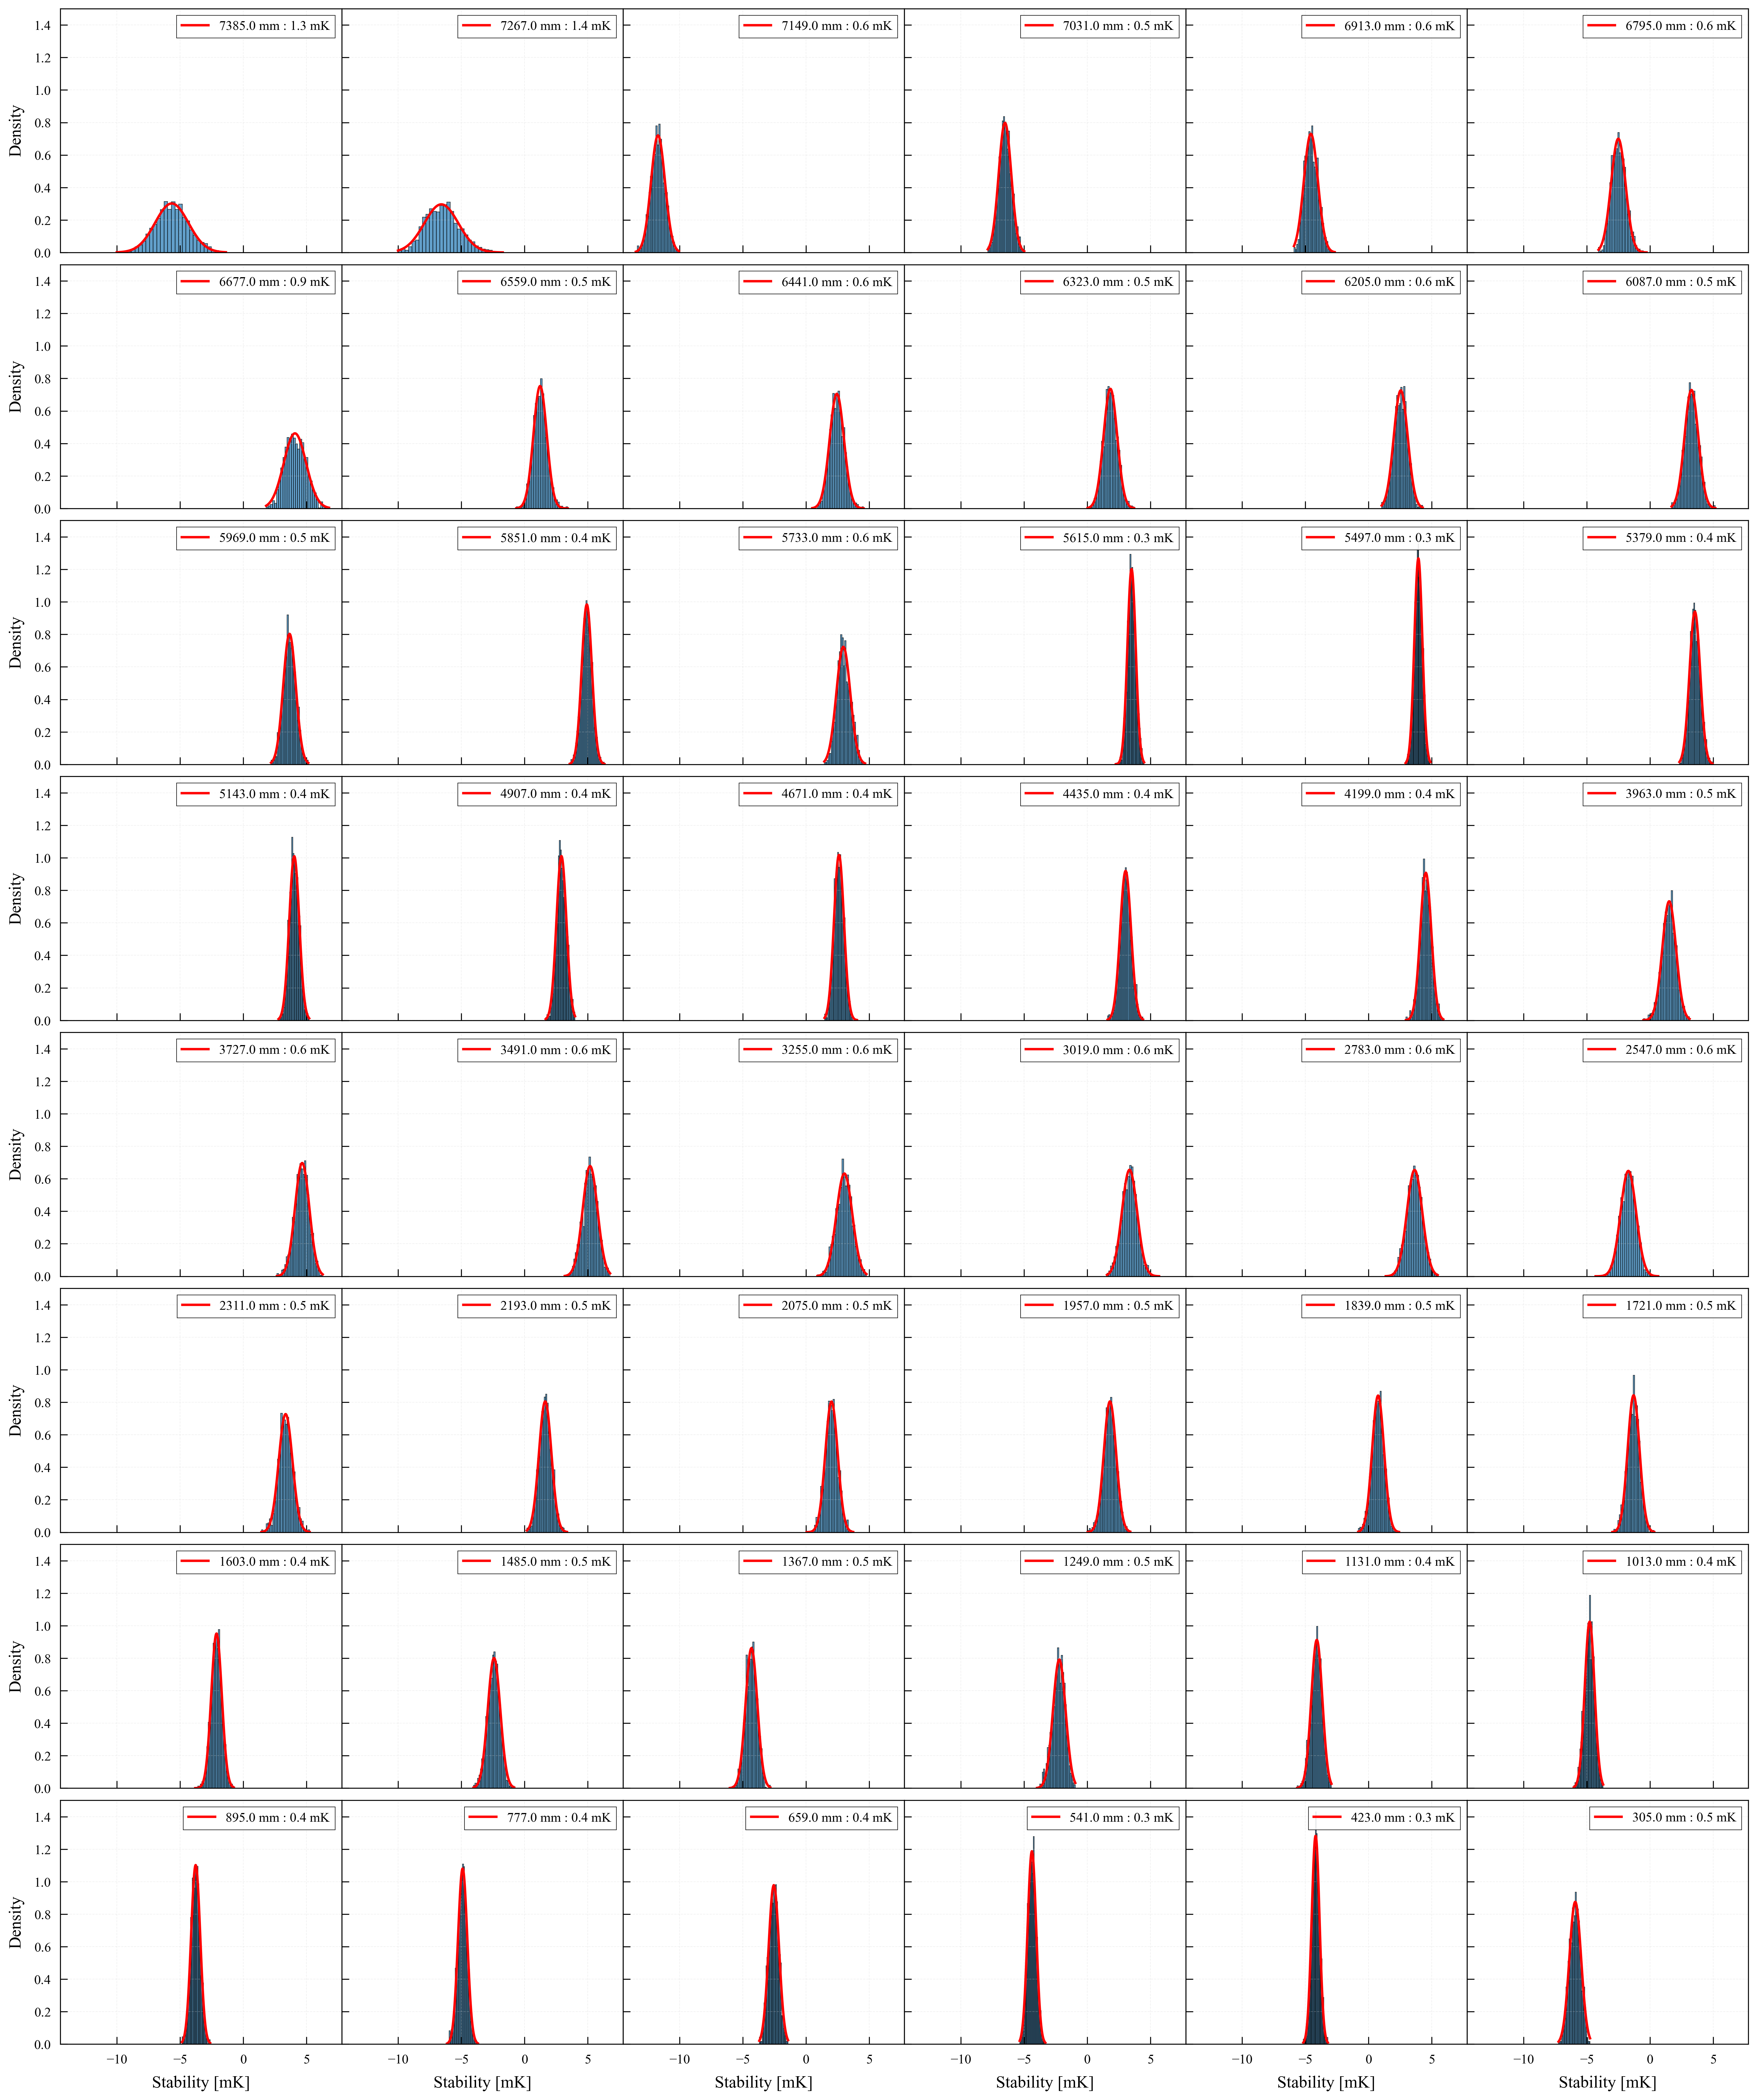

In [350]:
plot_gaussian_fits(gauss_tgrad_first, tgrad_combined)

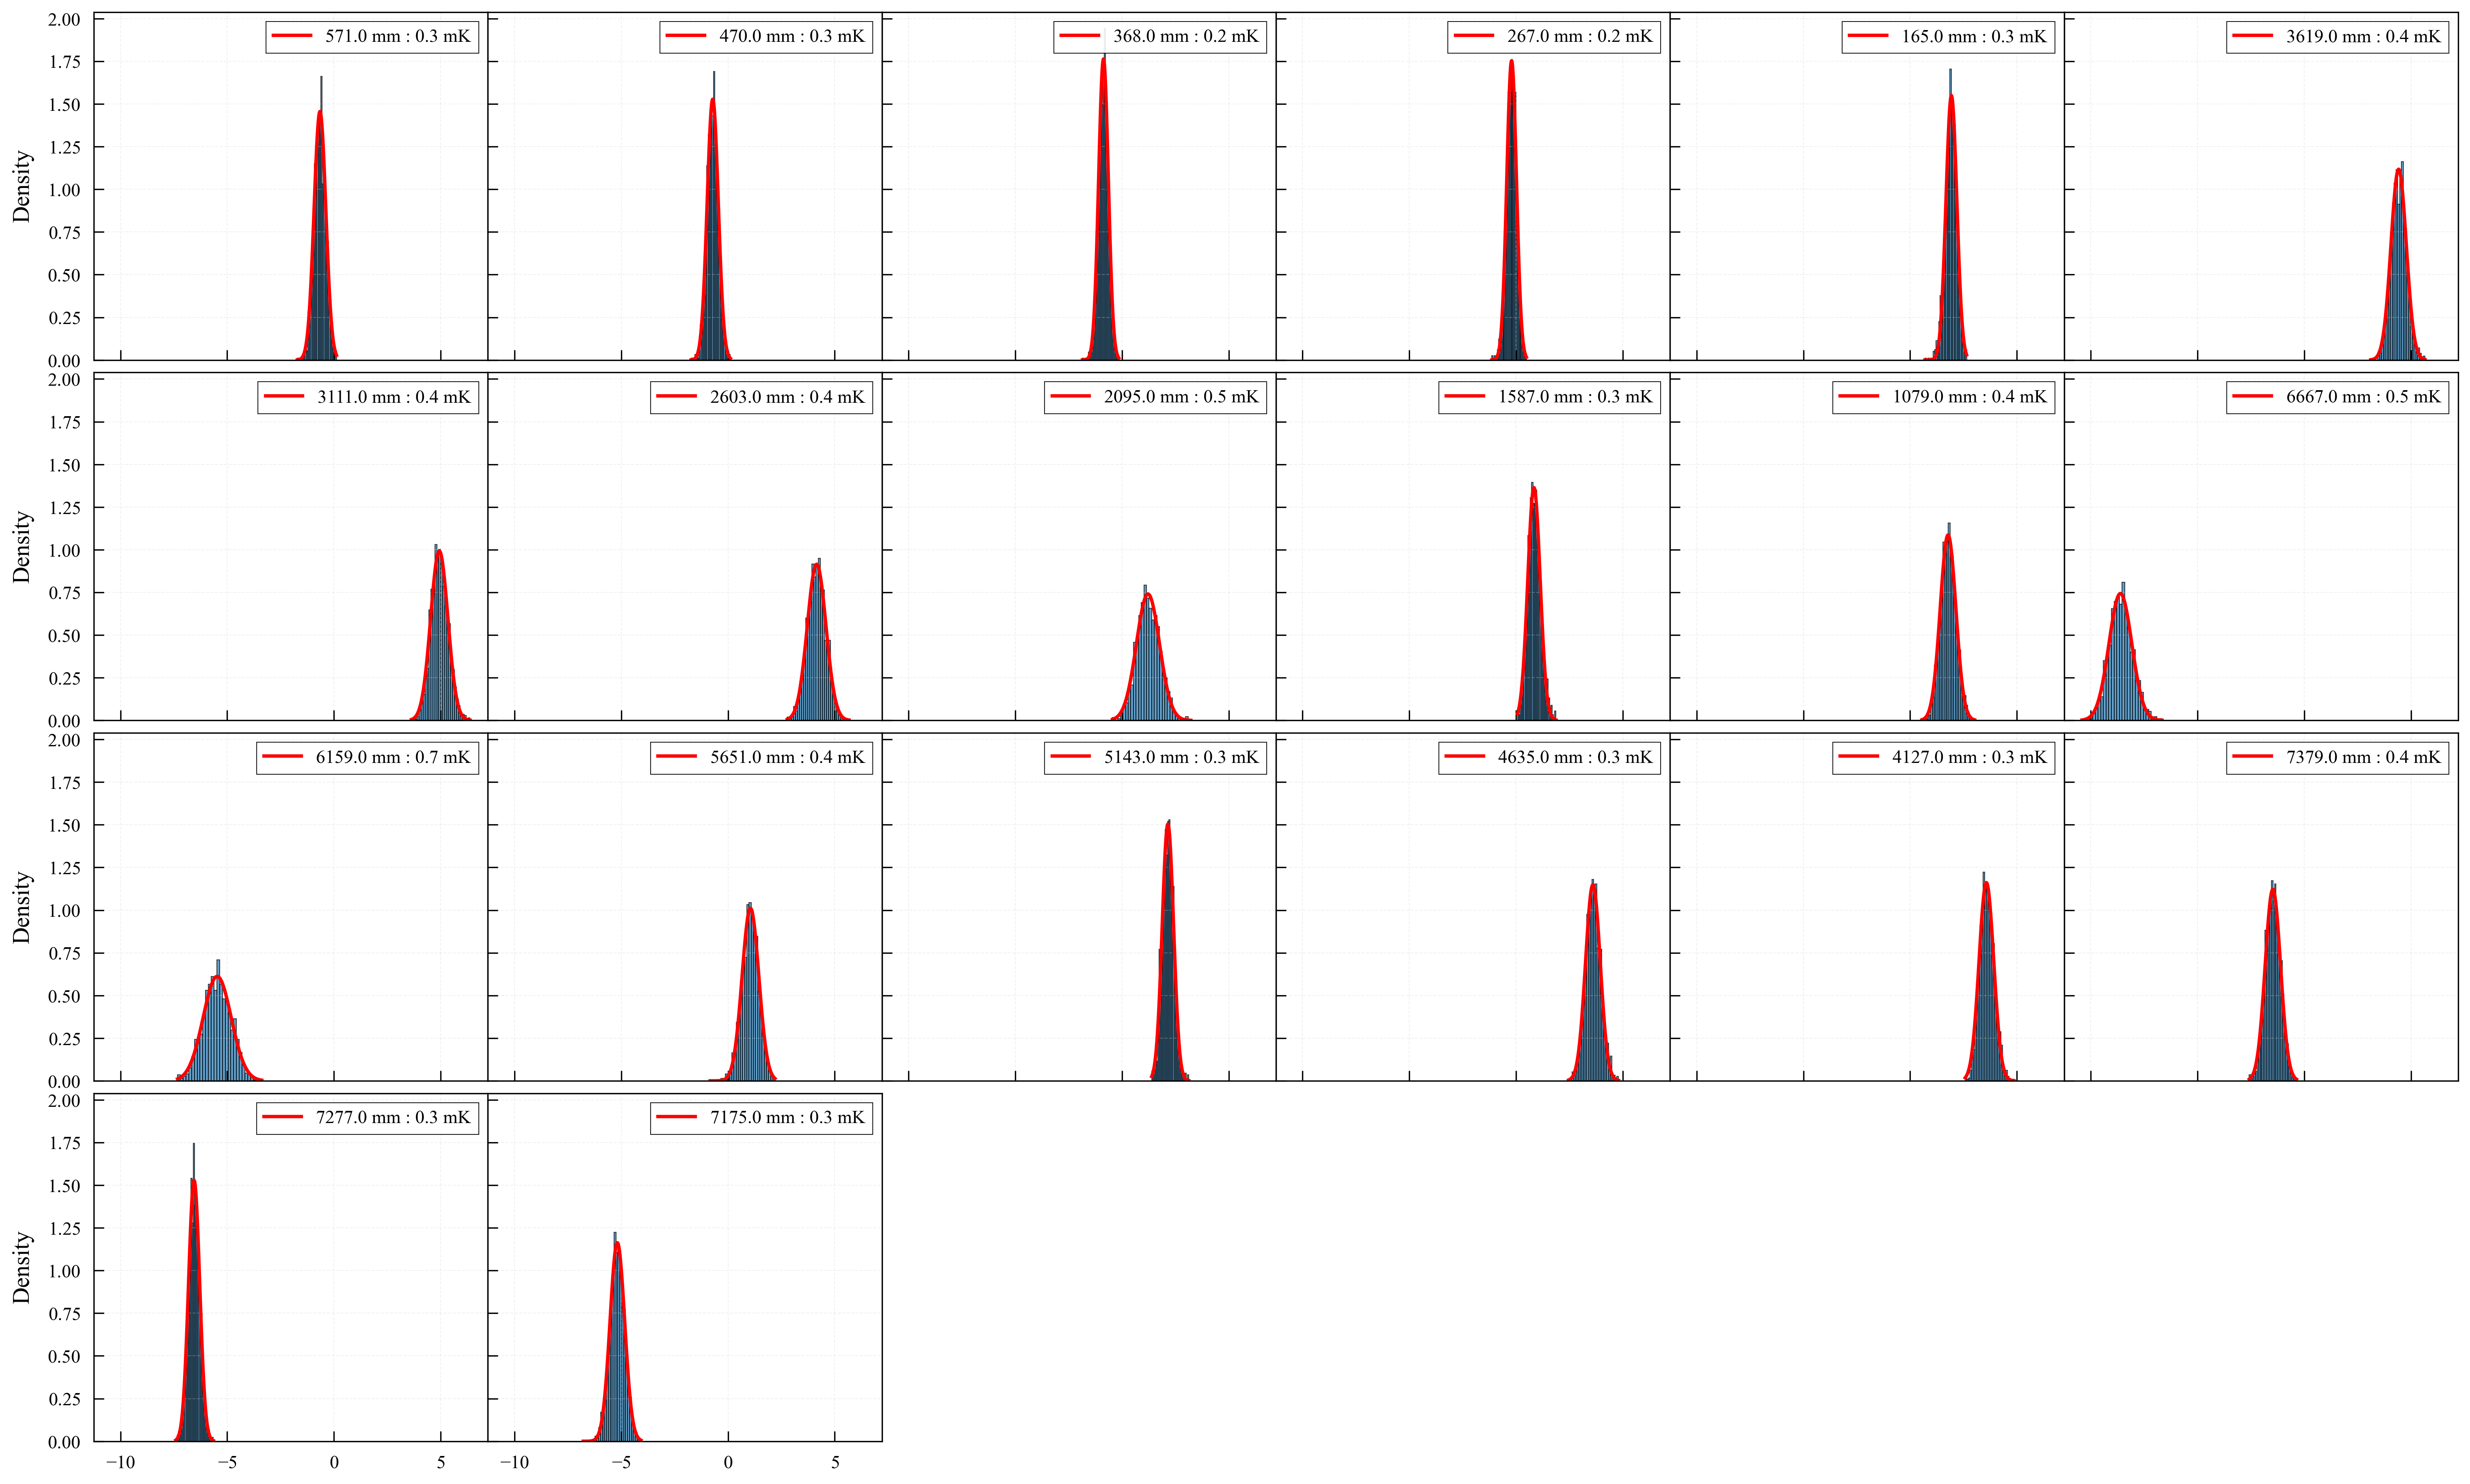

In [351]:
plot_gaussian_fits(gauss_hawai_first, hawai_combined)

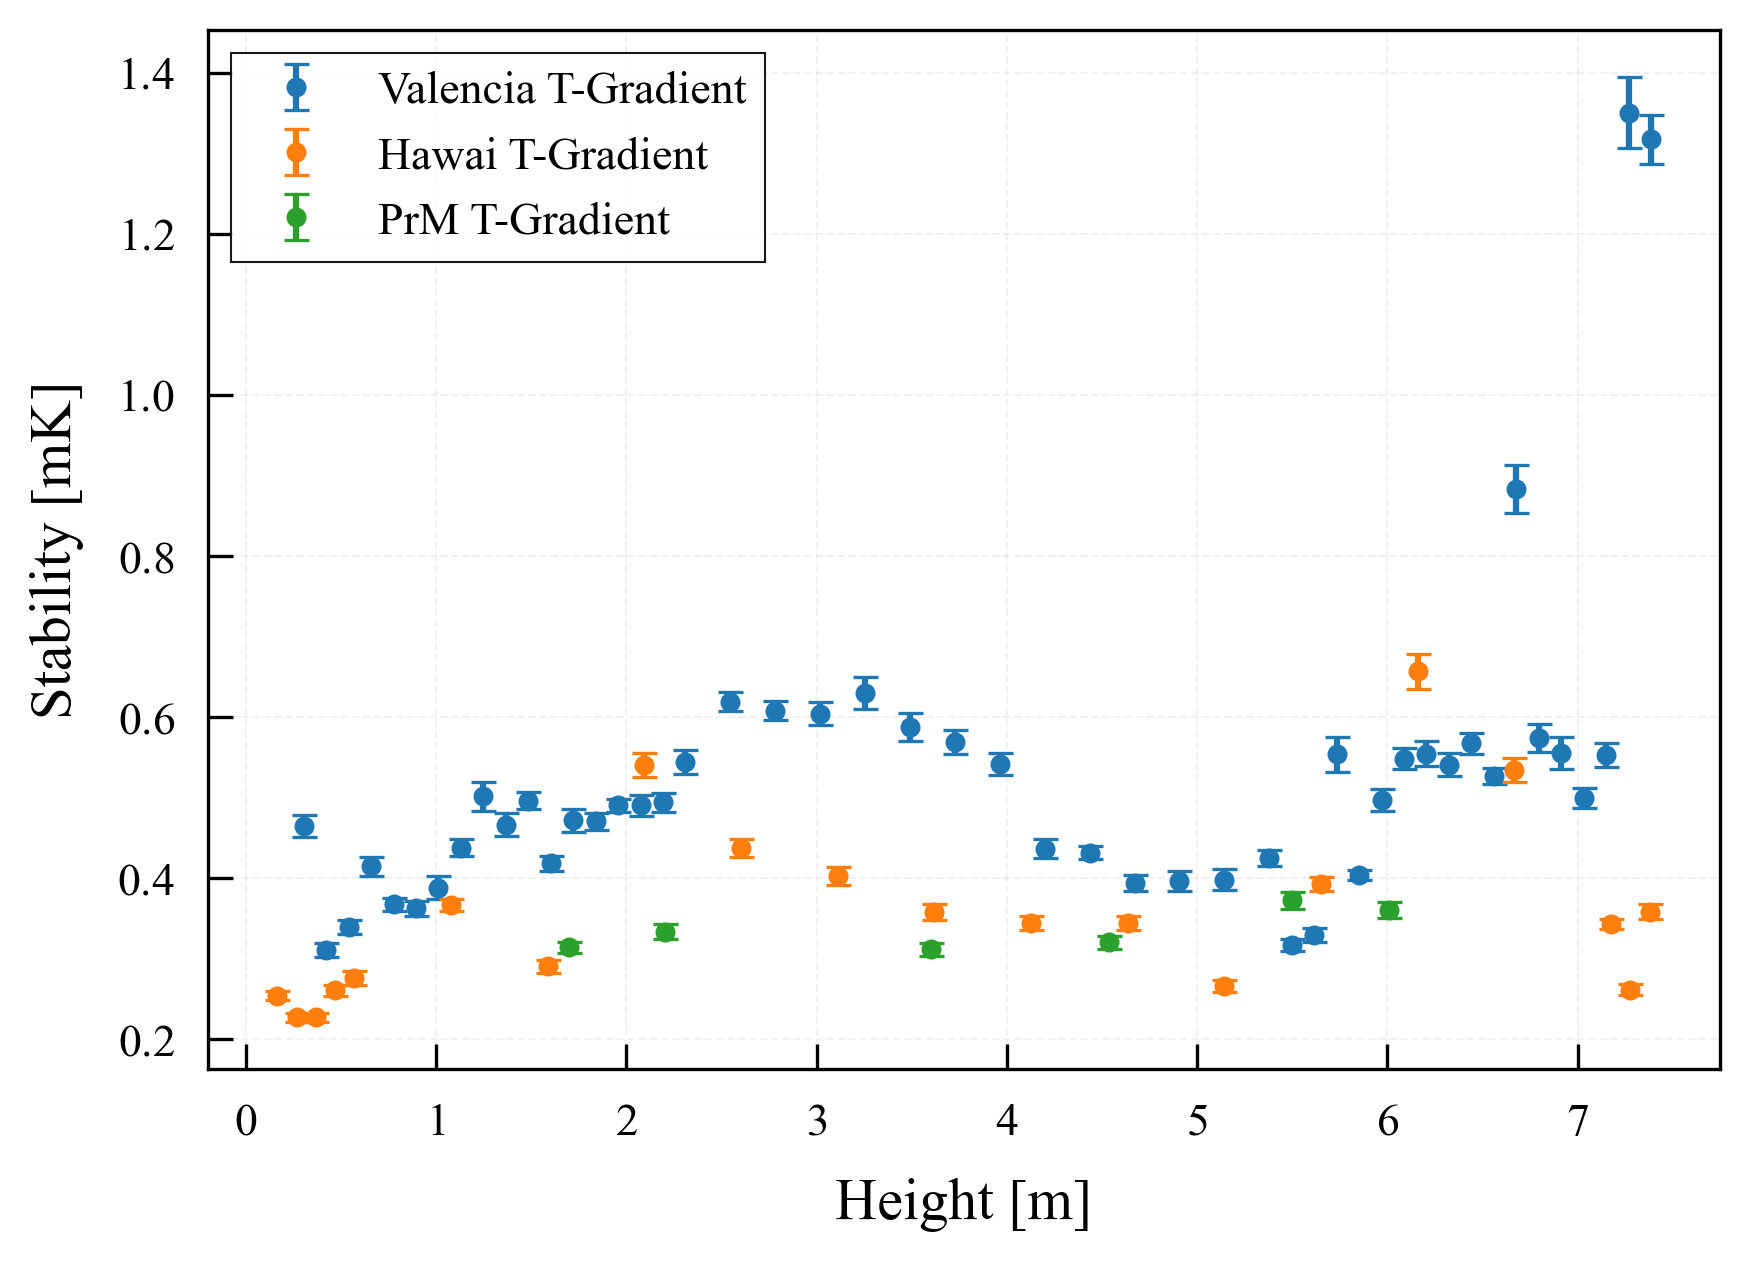

In [352]:
fig, axes = plt.subplots(1,1)
axes.errorbar(1e-3*gauss_tgrad_first["Y"].values, gauss_tgrad_first["sigma"].values, yerr=gauss_tgrad_first["sigma_err"].values, fmt="o", label="Valencia T-Gradient")
axes.errorbar(1e-3*gauss_hawai_first["Y"].values, gauss_hawai_first["sigma"].values, yerr=gauss_hawai_first["sigma_err"].values, fmt="o", label="Hawai T-Gradient")
axes.errorbar(1e-3*gauss_prm_first["Y"].values, gauss_prm_first["sigma"].values, yerr=gauss_prm_first["sigma_err"].values, fmt="o", label="PrM T-Gradient")
axes.set_xlabel("Height [m]")
axes.set_ylabel("Stability [mK]")
axes.legend()
fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/TMAPS/stability.png", dpi=300)

/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_24996/1856120081.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes.plot(datetime_fit, y_fit, 'r-', color="tab:blue", linewidth=2, label=fr"Slope: {1e3*m:.1f} mK/day")


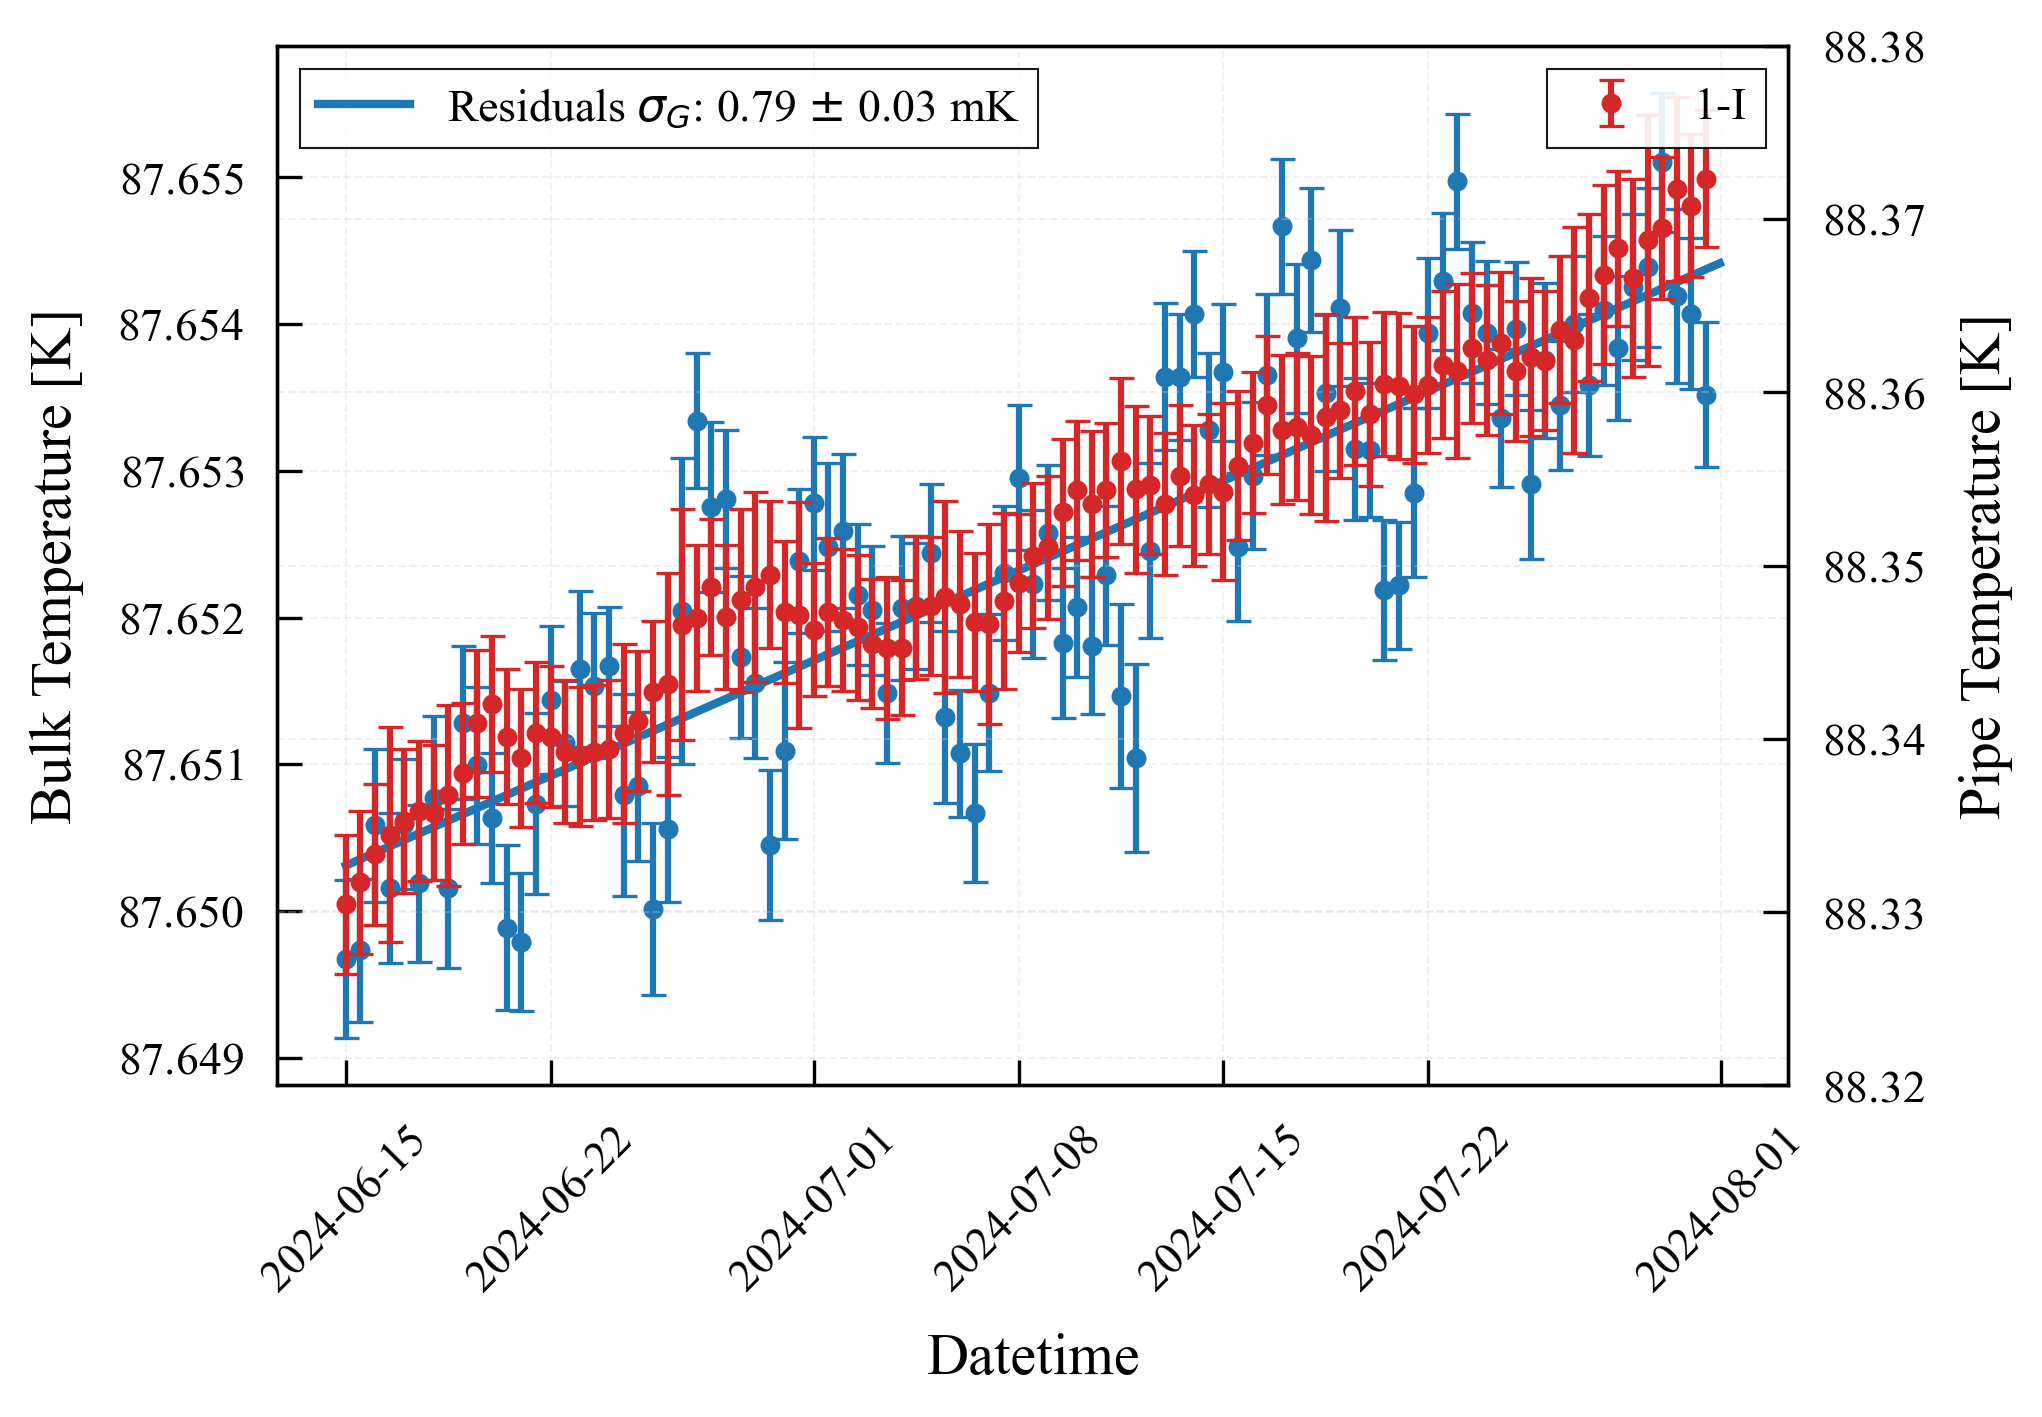

In [466]:
def line(x, m, b):
    return m*x + b

fig, axes = plt.subplots(1,1)
axes.errorbar(bulk_first.bulk["baseline"]["data"].resample("12H").mean().index.values, bulk_first.bulk["baseline"]["data"]["temp"].resample("12H").mean().values, yerr=bulk_first.bulk["baseline"]["data"]["temp"].resample("12H").std().values, fmt="o")
axes.set_xlabel("Datetime")
axes.set_ylabel("Bulk Temperature [K]")
axes.tick_params(axis='x', rotation=45)

# Convert to numeric (days since epoch)
datetime_index = bulk_first.bulk["baseline"]["data"].resample("45min").mean().dropna().index
numeric_times = datetime_index.astype('int64') / 1e9 / (24 * 3600)  # Convert nanoseconds to days
temp_values = bulk_first.bulk["baseline"]["data"]["temp"].resample("45min").mean().dropna().values

# Fit line
popt, _ = curve_fit(line, numeric_times, temp_values)
m, b = popt

# Create datetime range for plotting
start_date = datetime_index.min()
end_date = datetime_index.max()
datetime_fit = pd.date_range(start=start_date, end=end_date, periods=100)
numeric_fit = datetime_fit.astype('int64') / 1e9 / (24 * 3600)

# Calculate fitted line
y_fit = line(numeric_fit, m, b)

# Plot using datetime
axes.plot(datetime_fit, y_fit, 'r-', color="tab:blue", linewidth=2, label=fr"Slope: {1e3*m:.1f} mK/day")

residuals = bulk_first.bulk["baseline"]["data"]["temp"].resample("45min").mean().dropna().values - line(numeric_times, m, b)

hist, bin_edges = np.histogram(residuals, bins=30, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Initial guess for Gaussian parameters
mu_guess = np.mean(residuals)
sigma_guess = np.std(residuals)
A_guess = np.max(hist)

# Fit Gaussian
popt, pcov = curve_fit(gaussian, bin_centers, hist,
                    p0=[mu_guess, sigma_guess, A_guess],
                    maxfev=1000)

mu_fit, sigma_fit, A_fit = popt

mu_err = np.sqrt(pcov[0, 0])  # Error on mean
sigma_err = np.sqrt(pcov[1, 1])  # Error on sigma
A_err = np.sqrt(pcov[2, 2])  # Error on amplitude

axes.legend(
    [fr"Residuals $\sigma_G$: {1e3*sigma_fit:.2f} $\pm$ {1e3*sigma_err:.2f} mK"], loc="upper left"
)

axes2 = axes.twinx()
axes2.errorbar(pipes.sensors[49319].data.resample("12H").mean().index.values, pipes.sensors[49319].data.resample("12H").mean().values, yerr=pipes.sensors[49319].data.resample("12H").std().values, color="tab:red", fmt="o", linestyle="none", label=fr"{pipes.sensors[49319].name}")
axes2.set_ylabel("Pipe Temperature [K]")
axes2.set_ylim(88.32, 88.38)
axes2.legend(loc="upper right")
fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/TMAPS/stability_bulk_first.png", dpi=300)


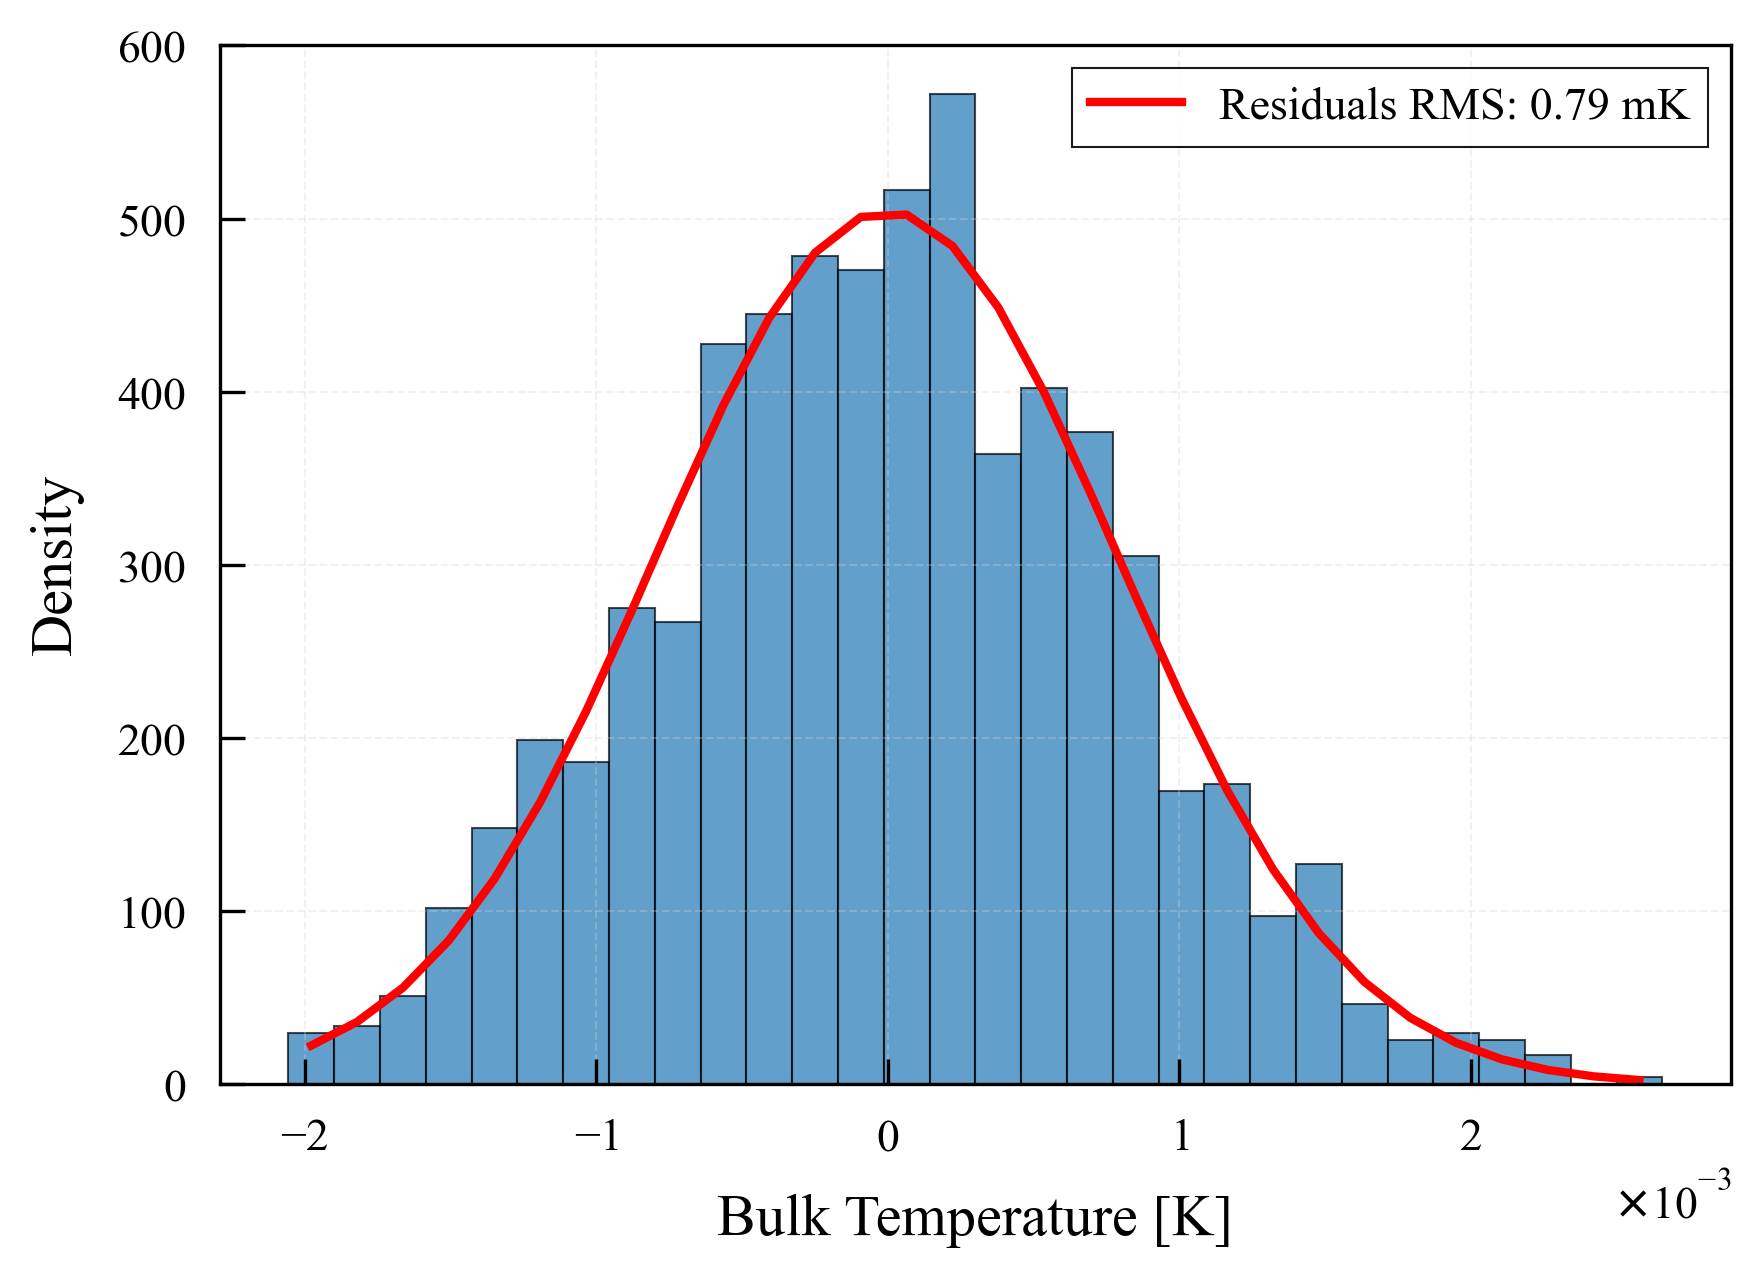

In [414]:
fig, axes = plt.subplots(1,1)
axes.hist(residuals, bins=30, density=True, alpha=0.7, color='tab:blue', edgecolor='black')
axes.set_xlabel("Bulk Temperature [K]")
axes.set_ylabel("Density")
axes.plot(bin_centers, gaussian(bin_centers, mu_fit, sigma_fit, A_fit), 'r-', linewidth=2, label=fr"Residuals RMS: {1e3*sigma_fit:.2f} mK")
axes.legend()
# axes.tick_params(axis='x', rotation=45)
# fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/TMAPS/stability_bulk_first.png", dpi=300)


# Second Normal Operation Period

Goal is to evaluate the stability of the temperature map during the second normal operation period

In [418]:
dataset = baseClasses.Data()

In [427]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 10, 15)) & (dataset.data.index < datetime.datetime(2024, 11, 1))) |
    ((dataset.data.index > datetime.datetime(2024, 11, 8)) & (dataset.data.index < datetime.datetime(2024, 11, 29)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [428]:
bulk_second = observableClasses.Bulk(dataset)

Configuration-aware bulk temperature setup:

Configuration: october
Time period: 2024-10-15 00:01:00 to 2024-11-28 23:59:00

  System: TGRAD
  Boards 1-4: 1.0, 2.0
  Channels: TE0001, TE0002, TE0003, TE0004, TE0005, TE0006, TE0007, TE0008, TE0009, TE0010 ... (+38 more)



  System: APA
  Boards 1-4: 3.0
  Channels: TE0049, TE0050, TE0051, TE0052, TE0055, TE0056, TE0057, TE0058, TE0061, TE0062 ... (+6 more)

  System: nan
  Boards 1-4: No boards 1-4
  Channels: 

  System: PP
  Boards 1-4: 4.0
  Channels: TE0073, TE0074

  System: PRM
  Boards 1-4: 4.0
  Channels: TE0079, TE0080, TE0081, TE0082, TE0083, TE0084

  System: PIPE
  Boards 1-4: 4.0
  Channels: TE0085, TE0086, TE0087, TE0088, TE0089, TE0090, TE0091, TE0092, TE0093, TE0094 ... (+2 more)


Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00, 10.31sensor/s]

ERROR: Channel (TE0120) not found


In [ ]:
bulk_second.define()


Processing configurations for bulk temperature calculation...

Processing configuration: october


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00,  9.82sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 48/48 [00:00<00:00, 100.55sensor/s]


      Debug sensor 39666: name='TGRAD1', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39665: name='TGRAD2', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39664: name='TGRAD3', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39667: name='TGRAD4', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39661: name='TGRAD5', system='TGRAD', board=1.0, calibrated=True
    TGRAD: 48 total sensors
      High precision (boards 1-4, calibrated): 48
      Far from inlets (>1500mm): 36
      Far from CE (>1500mm): 36
      Below interface (Y<6100mm): 25
      Final qualifying sensors: 25


Equalizing APA Sensors: 100%|██████████| 16/16 [00:00<00:00, 16.49sensor/s]
Calibrating APA Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 16/16 [00:00<00:00, 99.96sensor/s] 


    APA: 16 total sensors
      High precision (boards 1-4, calibrated): 0
      Far from inlets (>1500mm): 0
      Far from CE (>1500mm): 0
      Below interface (Y<6100mm): 0
      Final qualifying sensors: 0
ERROR: System (nan) not found


...

ERROR: Channel (TE0120) not found


Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  7.77sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 86.42sensor/s]


    PIPE: 12 total sensors
      High precision (boards 1-4, calibrated): 12
      Far from inlets (>1500mm): 4
      Far from CE (>1500mm): 4
      Below interface (Y<6100mm): 4
      Final qualifying sensors: 4
Configuration october: 37 sensors included from systems ['TGRAD', 'APA', nan, 'PP', 'PRM', 'PIPE']


In [355]:
tgrad = systemClasses.System(dataset, "TGRAD")
# hawai = systemClasses.System(dataset, "HAWAI")
prm = systemClasses.System(dataset, "PRM")
tgrad.calibrate("SECOND_POFF_OCTOBER")
# hawai.calibrate("FIRST_POFF_PRECISION")
prm.calibrate("SECOND_POFF_OCTOBER")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00, 10.60sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 48/48 [00:00<00:00, 94.91sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00,  9.30sensor/s]
Calibrating PRM Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 6/6 [00:00<00:00, 78.98sensor/s]


In [356]:
tgrad.makeProfiles(deltat=45)
# hawai.makeProfiles(deltat=45)
prm.makeProfiles(deltat=45)

Calculating TGRAD temperature profiles every 45 minutes: : 1440step [00:25, 57.05step/s]                      
Calculating PRM temperature profiles every 45 minutes: : 1440step [00:03, 417.89step/s]                      


In [ ]:
tgrad_combined = combine_profiles(tgrad)
# hawai_combined = combine_profiles(hawai)
prm_combined = combine_profiles(prm)

In [367]:
gauss_tgrad_second = fit_gaussian_per_coord(tgrad_combined)
gauss_tgrad_second.drop(gauss_tgrad_second.index[gauss_tgrad_second["Y"]==777.0], inplace=True)
# gauss_hawai = fit_gaussian_per_coord(hawai_combined)
gauss_prm_second = fit_gaussian_per_coord(prm_combined)

Fit failed for (1514.0,6205.0,861.0)
Fit failed for (1514.0,1839.0,861.0)
Fit failed for (1514.0,1721.0,861.0)
Fit failed for (1514.0,1485.0,861.0)


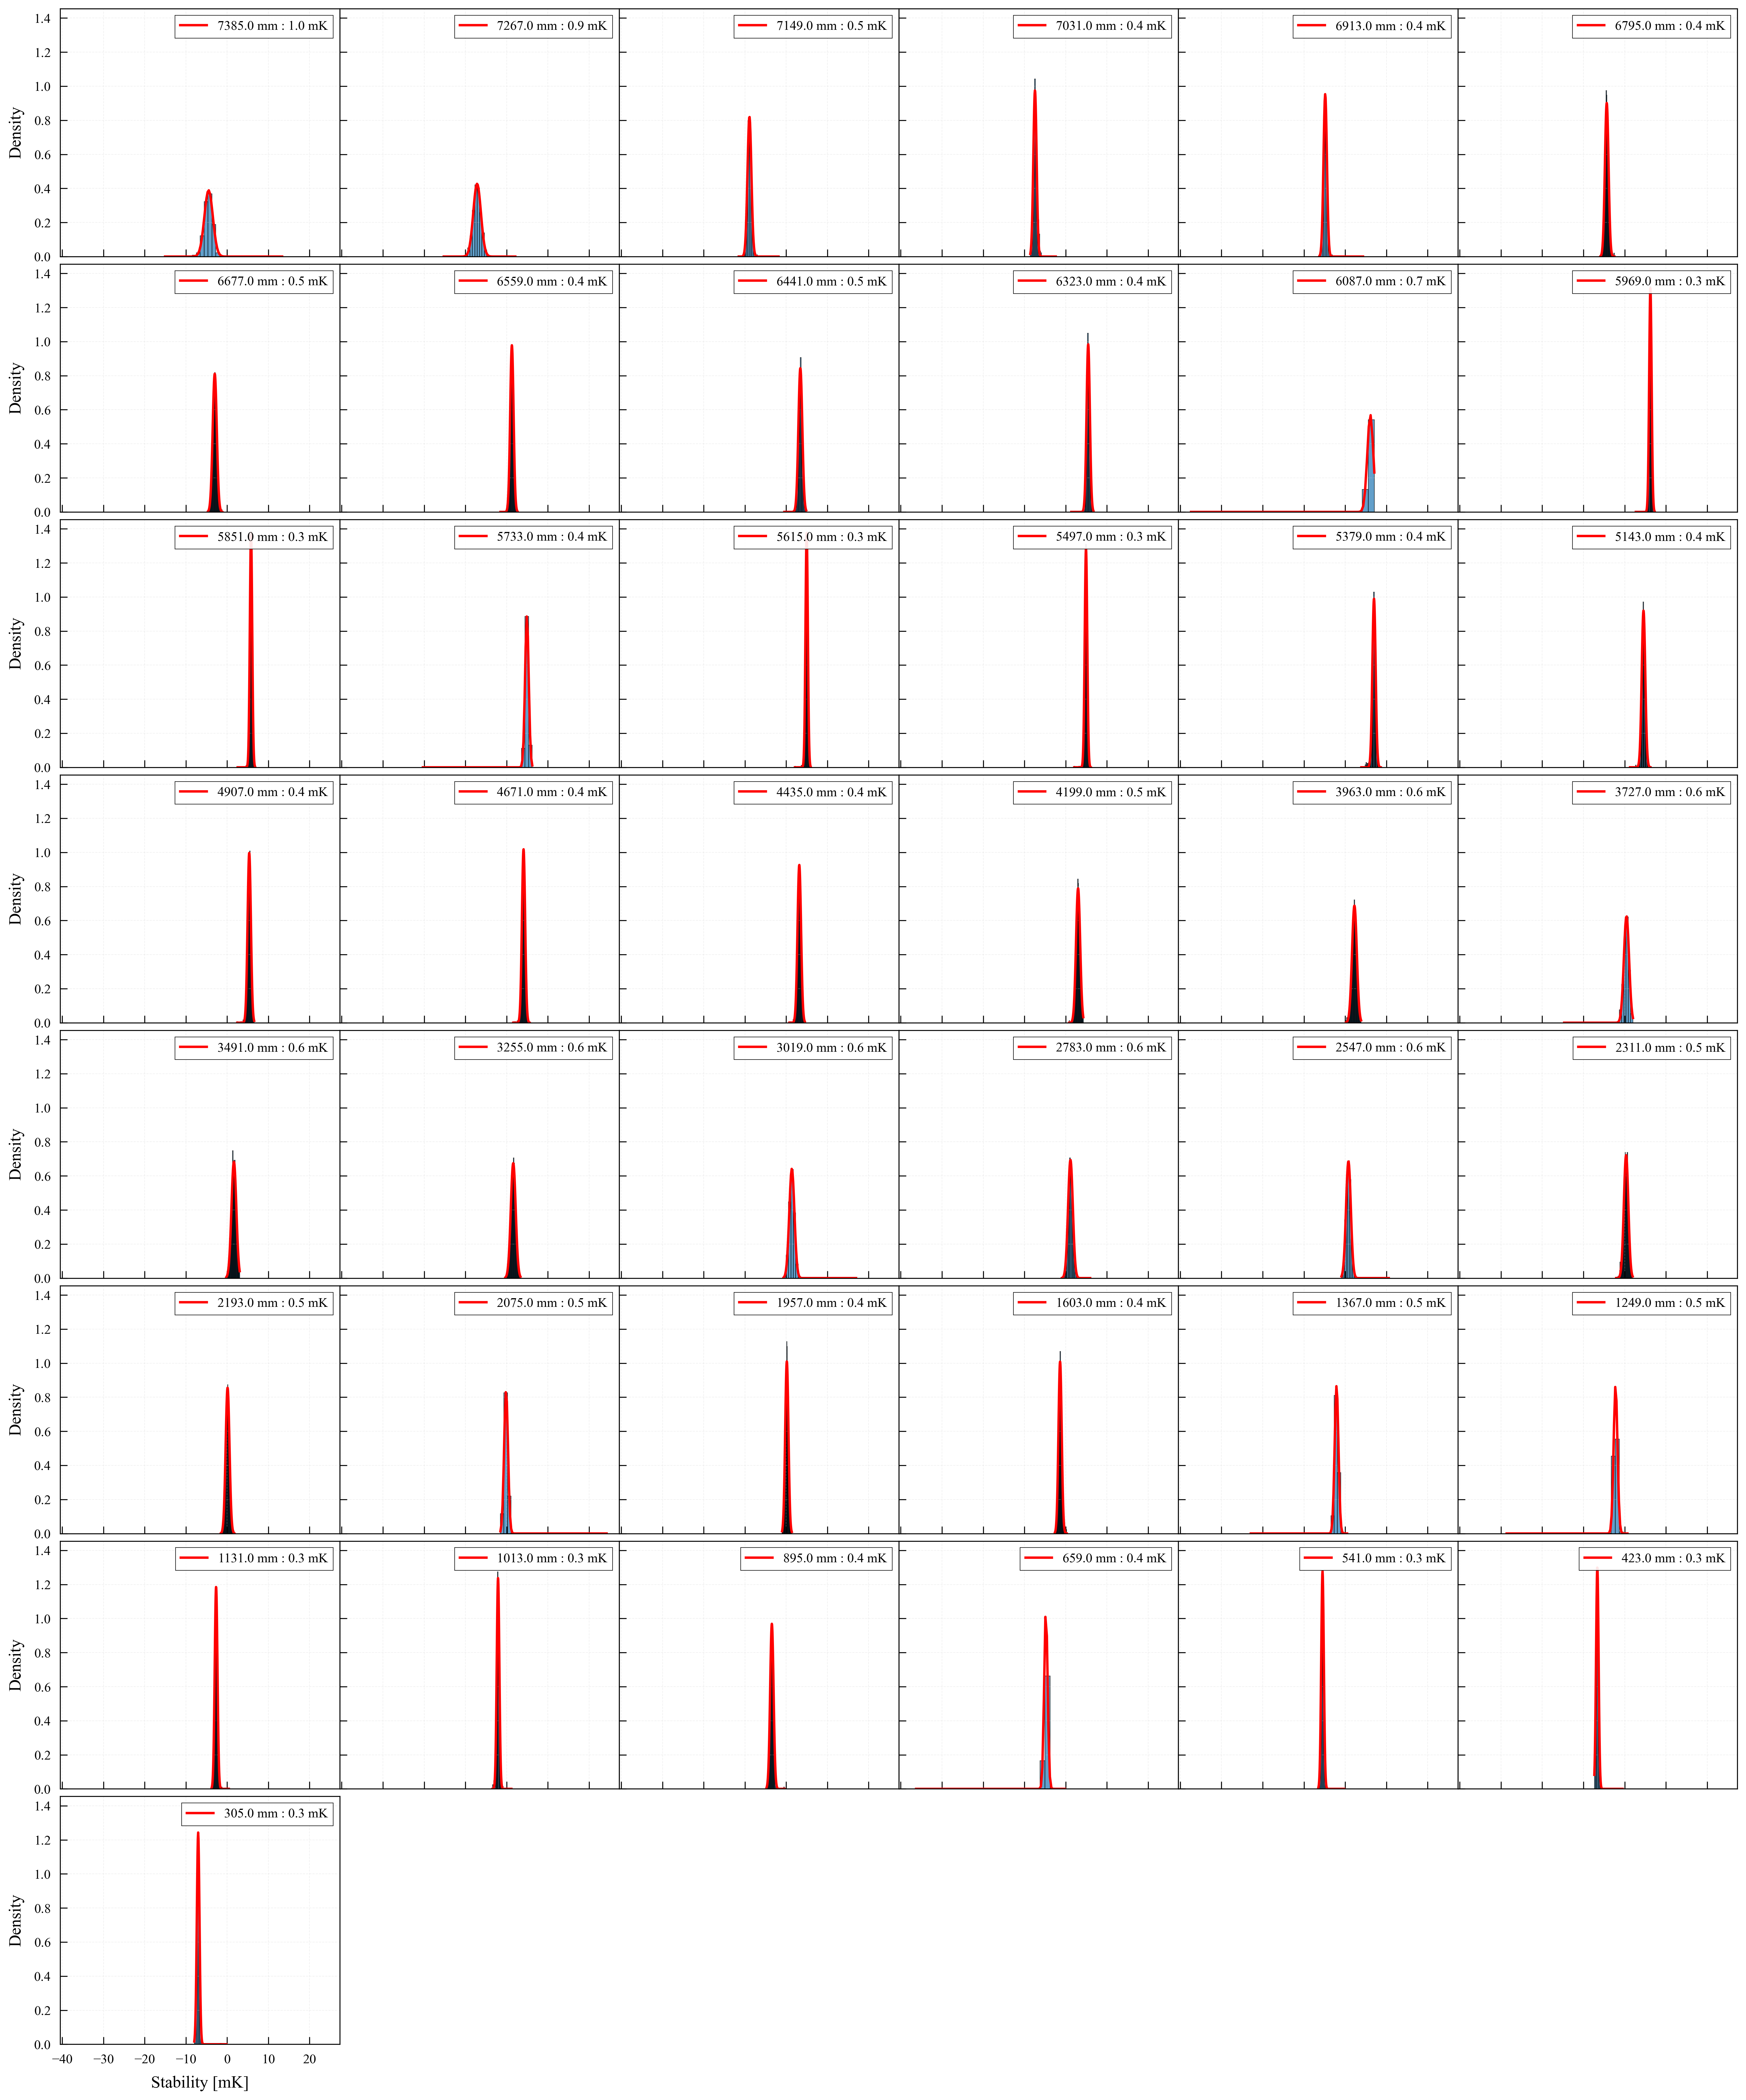

In [368]:
plot_gaussian_fits(gauss_tgrad_second, tgrad_combined)

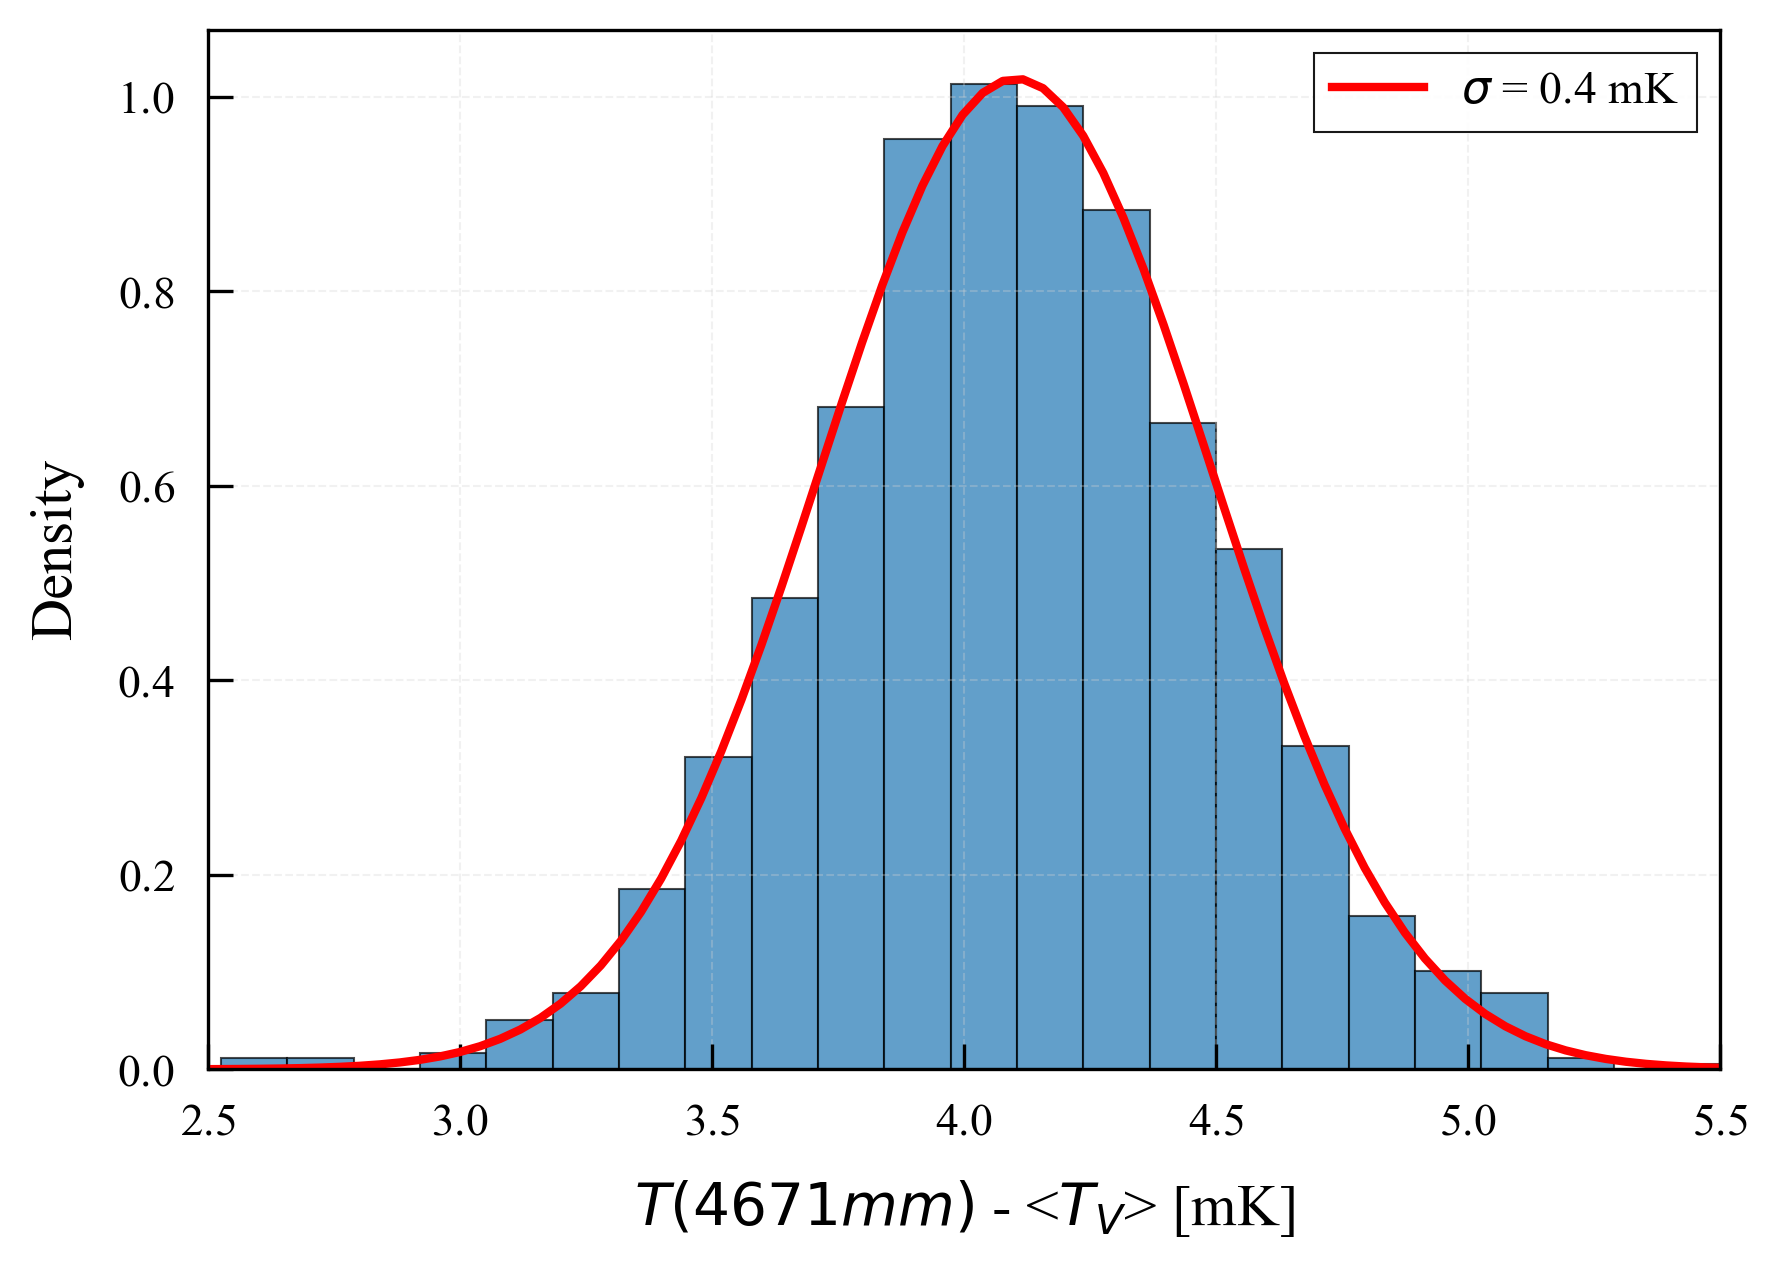

In [482]:
plot_gaussian_fit(gauss_tgrad_second, tgrad_combined, 4671)

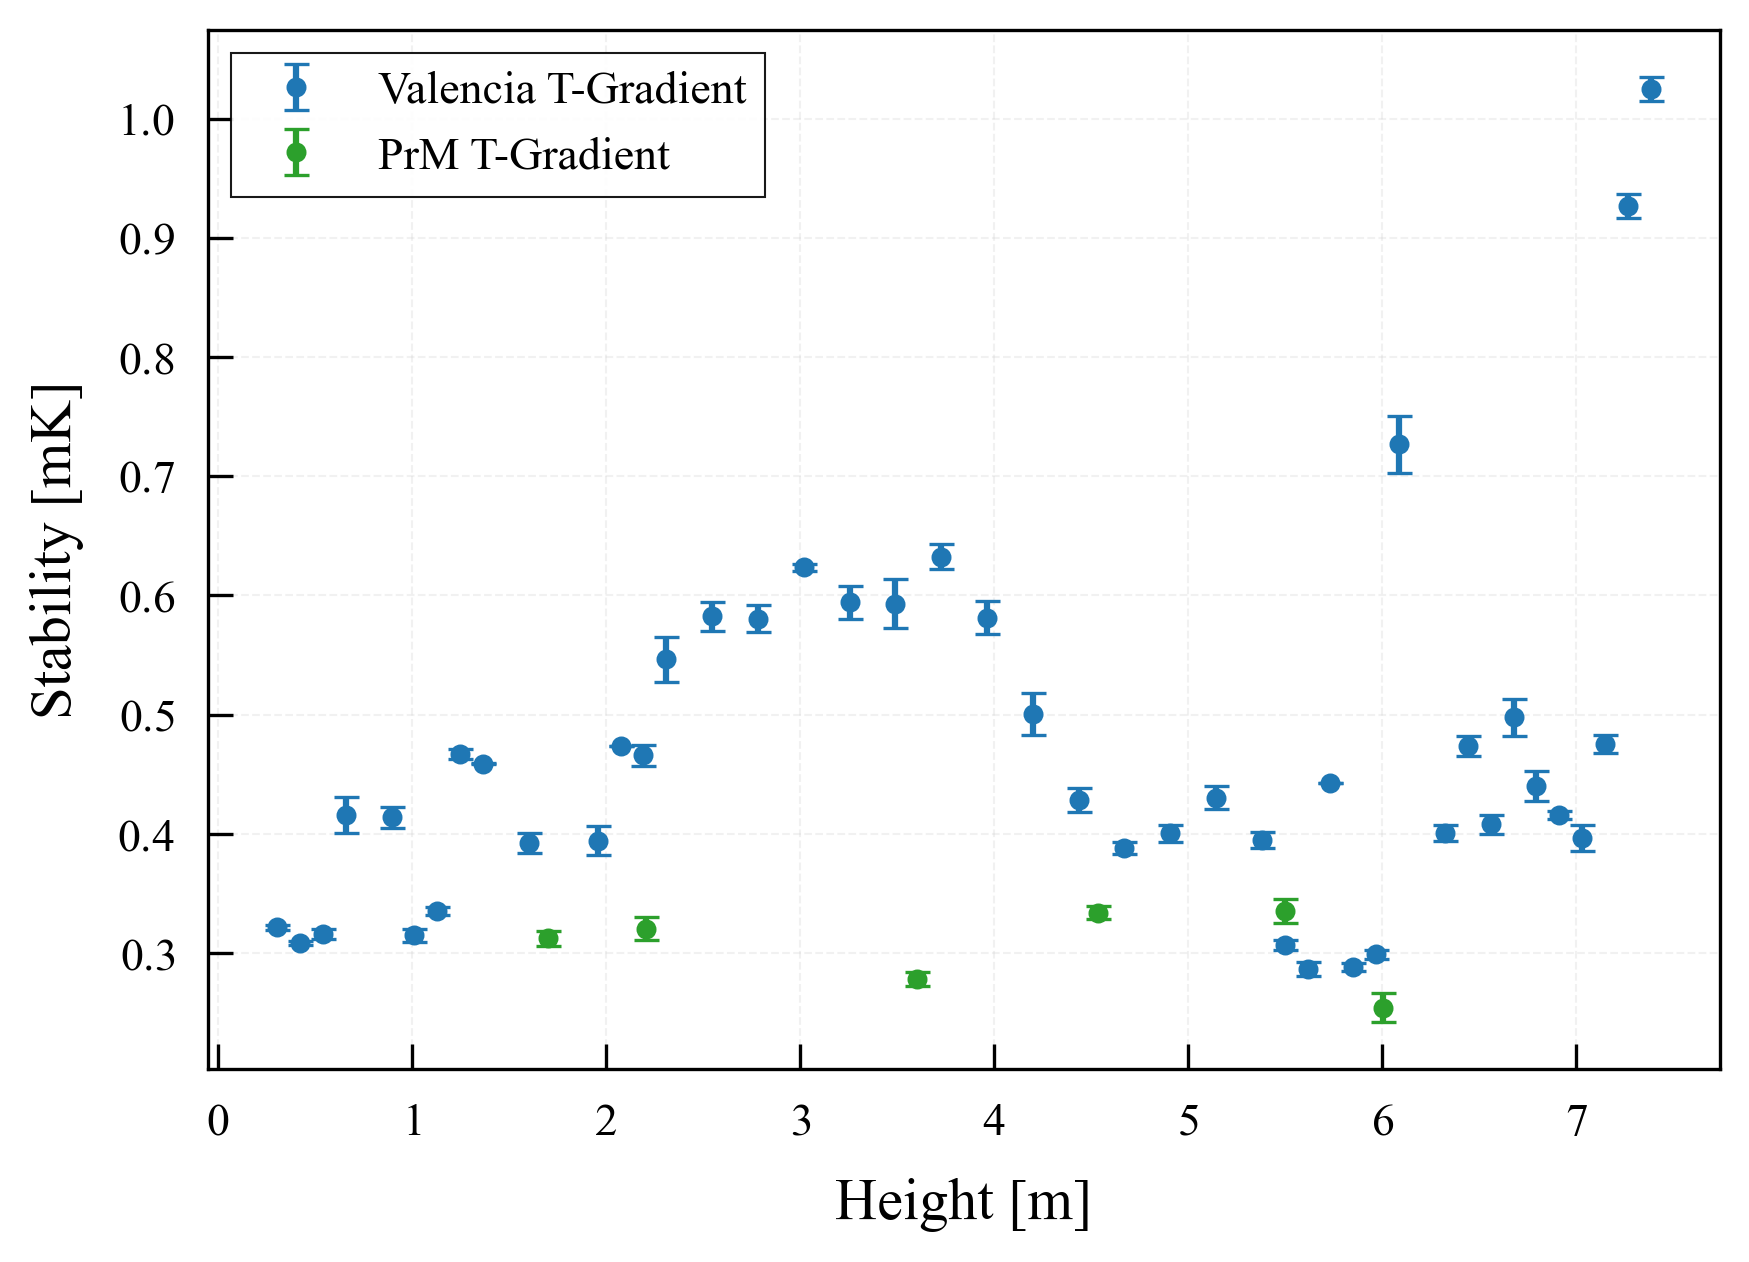

In [374]:
fig, axes = plt.subplots(1,1)
axes.errorbar(1e-3*gauss_tgrad_second["Y"].values, gauss_tgrad_second["sigma"].values, yerr=gauss_tgrad_second["sigma_err"].values, fmt="o", label="Valencia T-Gradient")
# axes.errorbar(1e-3*gaussian_results_hawai["Y"].values, gaussian_results_hawai["sigma"].values, yerr=gaussian_results_hawai["sigma_err"].values, fmt="o", label="Hawai T-Gradient")
axes.errorbar(1e-3*gauss_prm_second["Y"].values, gauss_prm_second["sigma"].values, yerr=gauss_prm_second["sigma_err"].values, fmt="o", color="tab:green", label="PrM T-Gradient")
axes.set_xlabel("Height [m]")
axes.set_ylabel("Stability [mK]")
axes.legend()
fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/TMAPS/stability_second.png", dpi=300)

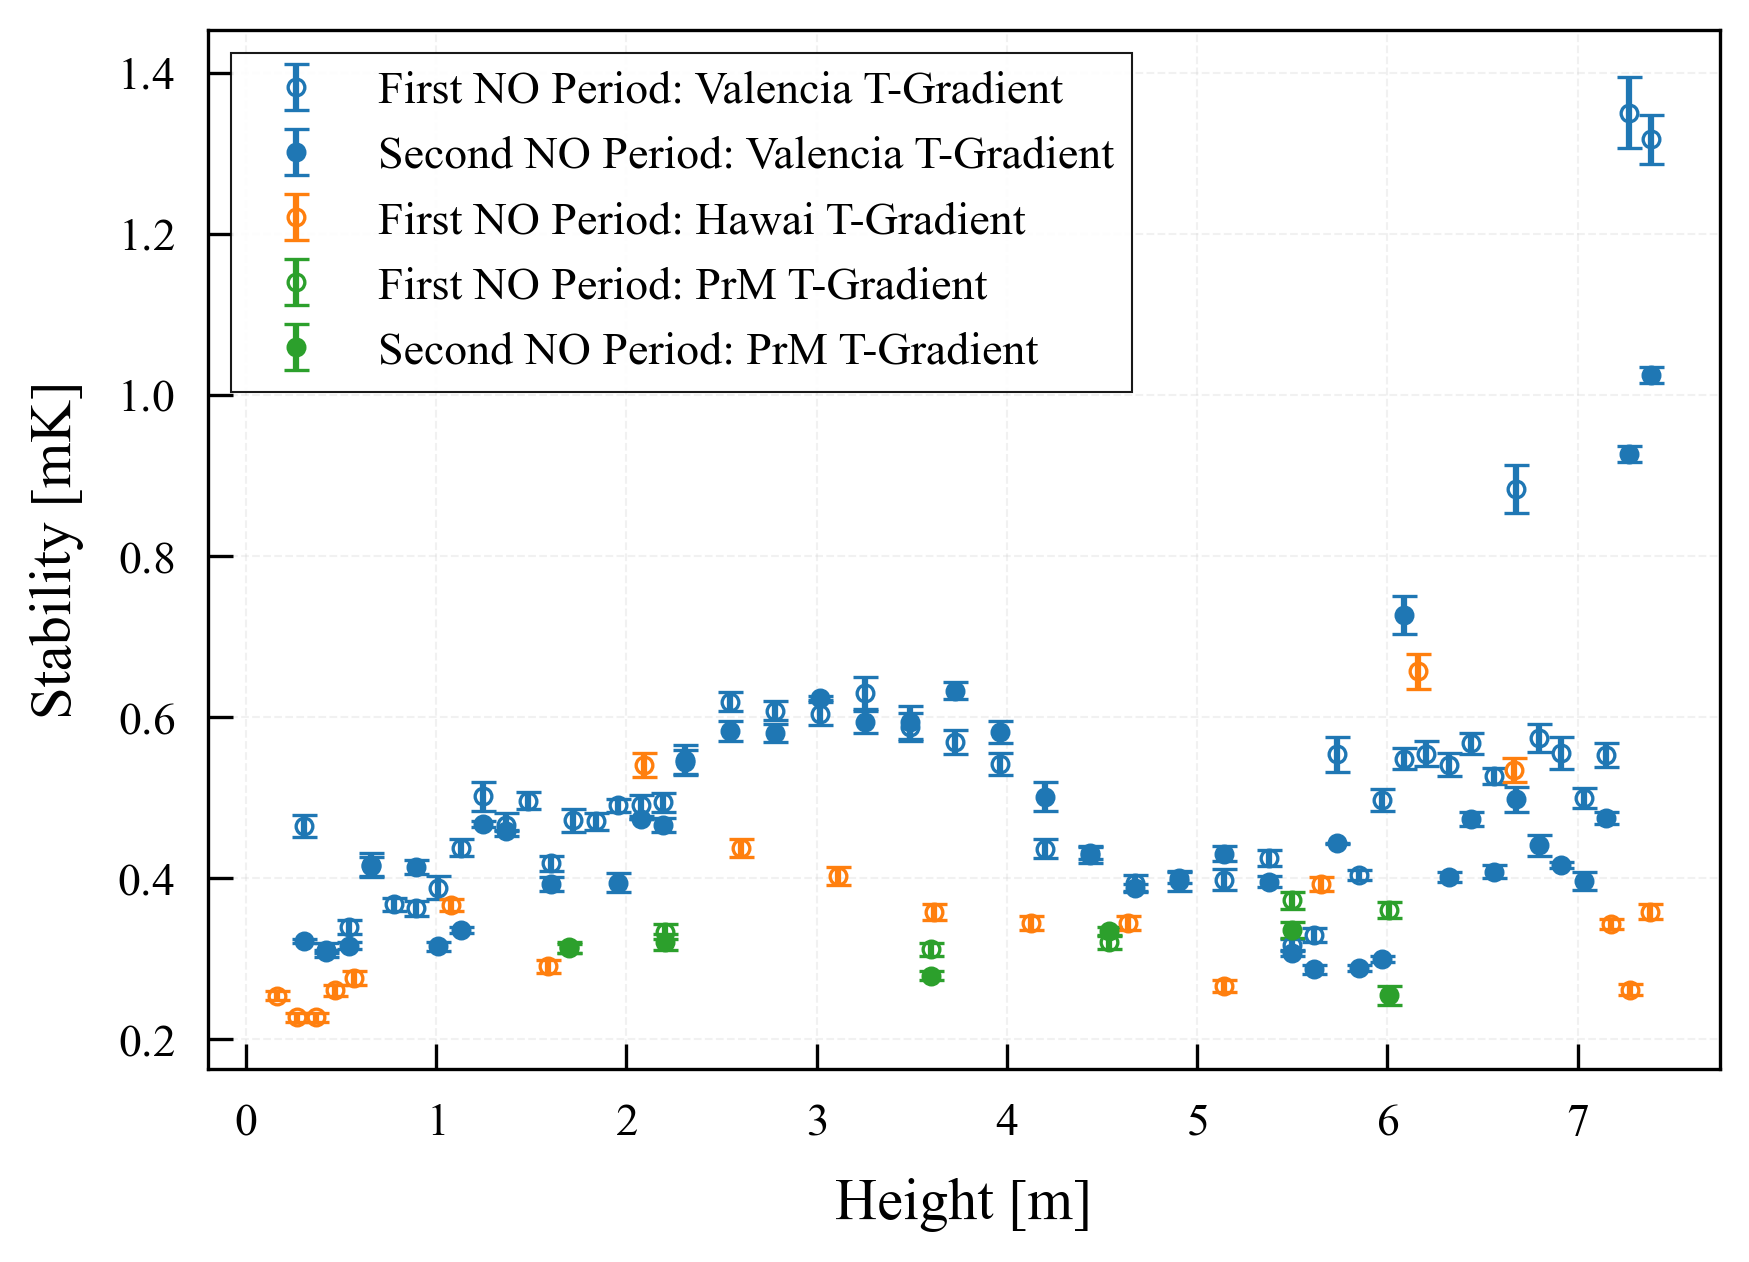

In [375]:
fig, axes = plt.subplots(1,1)
axes.errorbar(1e-3*gauss_tgrad_first["Y"].values, gauss_tgrad_first["sigma"].values, yerr=gauss_tgrad_first["sigma_err"].values, fmt="o", color="tab:blue", markerfacecolor="none", label="First NO Period: Valencia T-Gradient")
axes.errorbar(1e-3*gauss_tgrad_second["Y"].values, gauss_tgrad_second["sigma"].values, yerr=gauss_tgrad_second["sigma_err"].values, fmt="o", label="Second NO Period: Valencia T-Gradient")
axes.errorbar(1e-3*gauss_hawai_first["Y"].values, gauss_hawai_first["sigma"].values, yerr=gauss_hawai_first["sigma_err"].values, fmt="o", markerfacecolor="none", label="First NO Period: Hawai T-Gradient")
axes.errorbar(1e-3*gauss_prm_first["Y"].values, gauss_prm_first["sigma"].values, yerr=gauss_prm_first["sigma_err"].values, fmt="o", color="tab:green", markerfacecolor="none", label="First NO Period: PrM T-Gradient")
axes.errorbar(1e-3*gauss_prm_second["Y"].values, gauss_prm_second["sigma"].values, yerr=gauss_prm_second["sigma_err"].values, fmt="o", color="tab:green", label="Second NO Period: PrM T-Gradient")
axes.set_xlabel("Height [m]")
axes.set_ylabel("Stability [mK]")
axes.legend()
fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/TMAPS/stability_first_second.png", dpi=300)

In [431]:
pipes = systemClasses.System(dataset, "PIPE")
pipes.calibrate("SECOND_POFF_OCTOBER")

Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  8.10sensor/s]


ERROR: Channel (TE0120) not found


Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  9.87sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 18.65sensor/s]


In [441]:
pump_diff = sensorClasses.Sensor(dataset, id=1048)

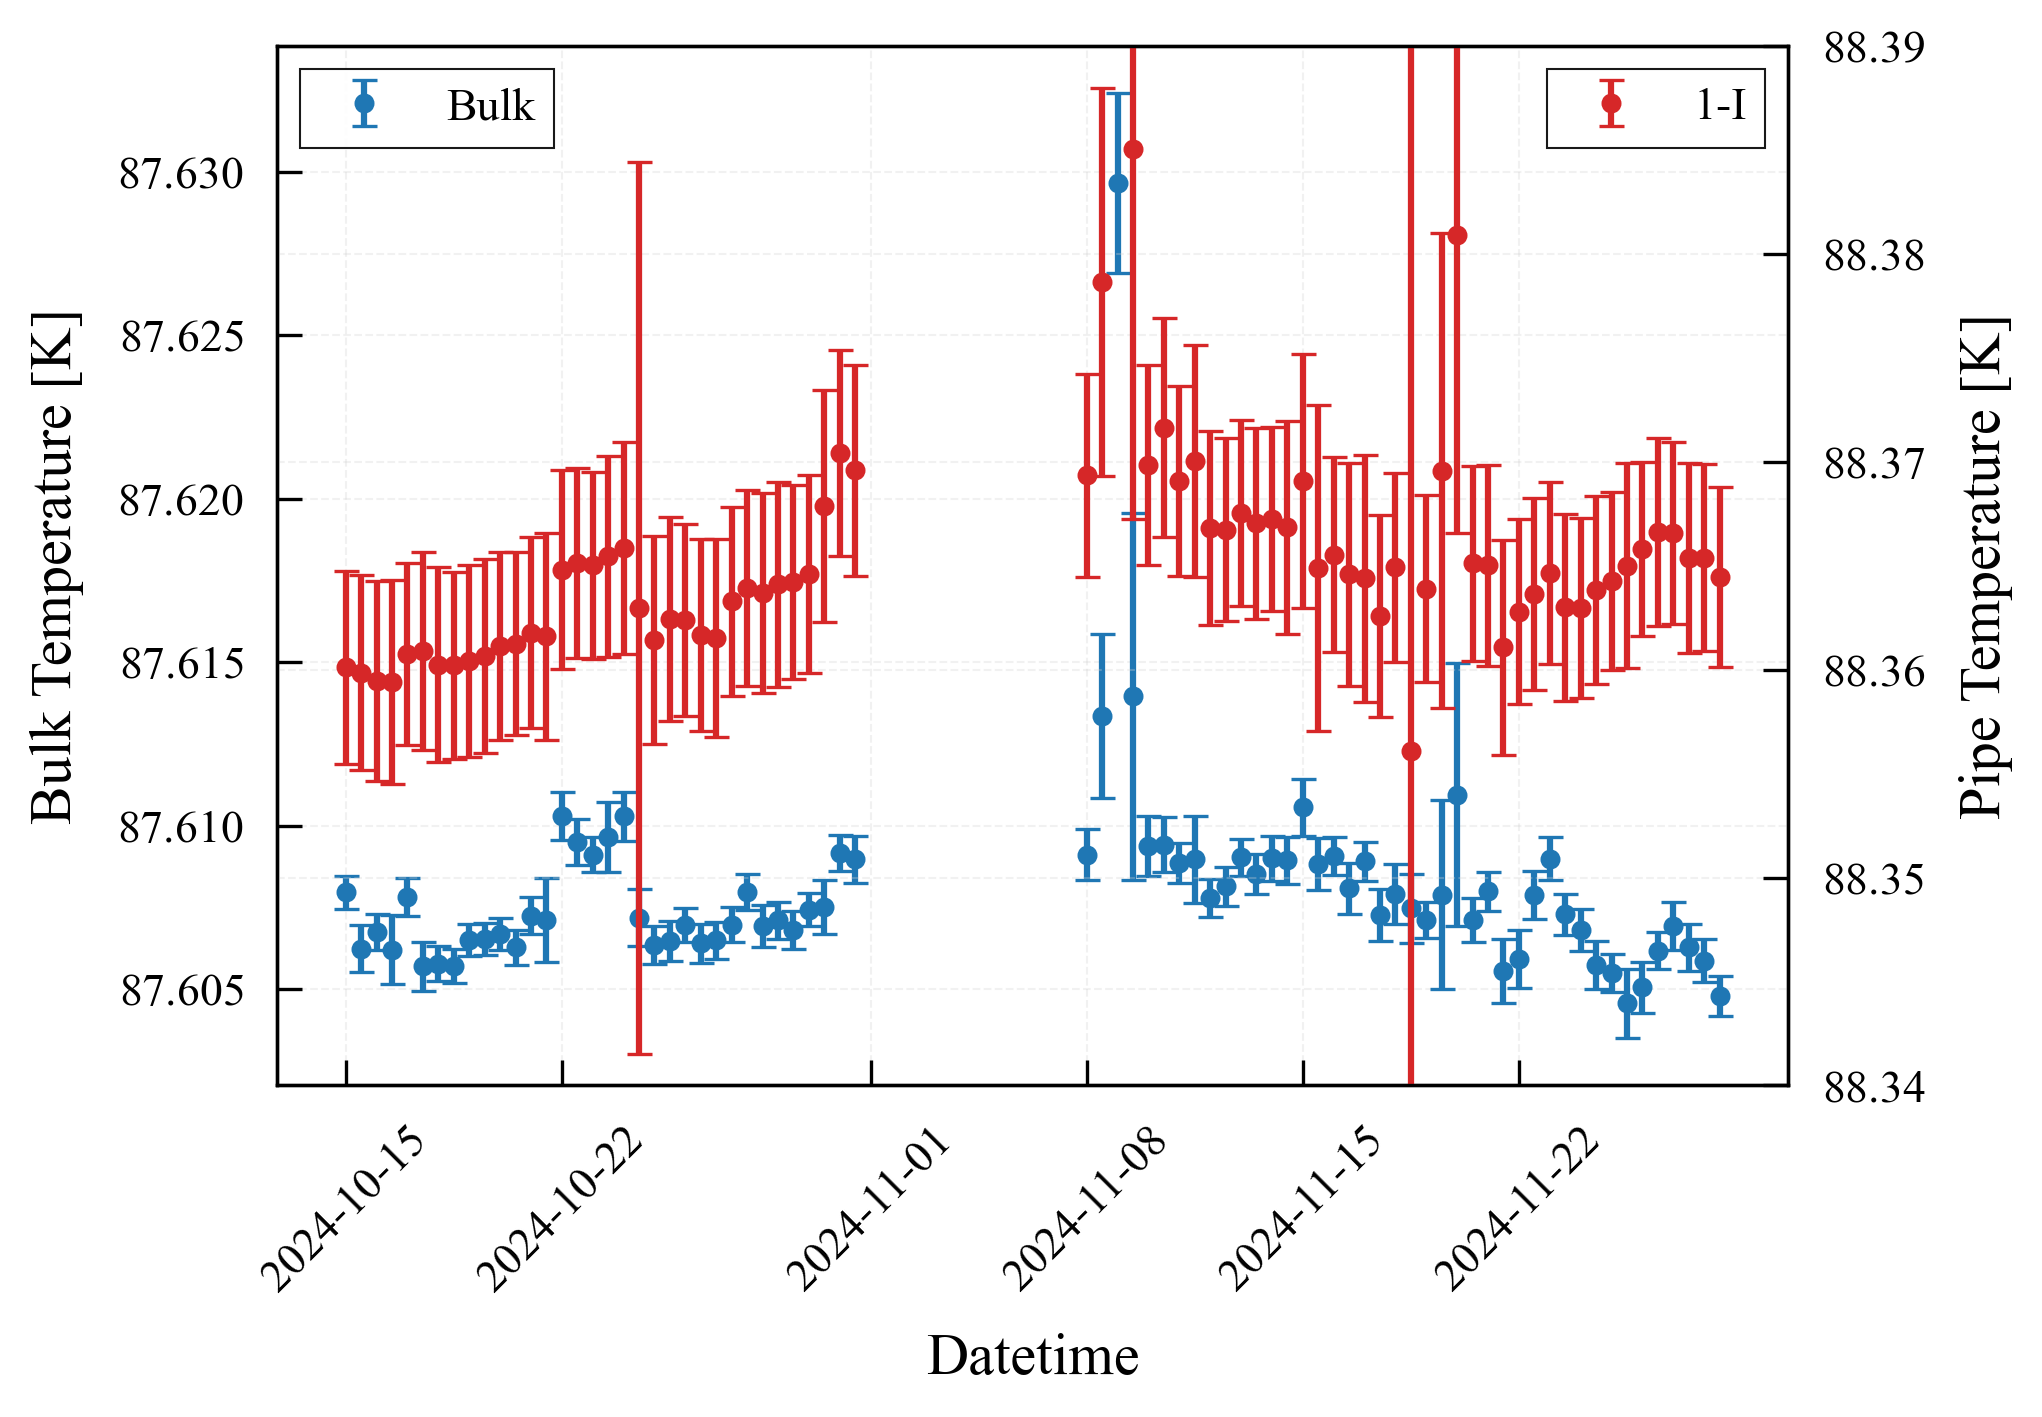

In [451]:
def line(x, m, b):
    return m*x + b

fig, axes = plt.subplots(1,1)
axes.errorbar(bulk_second.bulk["october"]["data"].resample("12H").mean().index.values, bulk_second.bulk["october"]["data"]["temp"].resample("12H").mean().values, yerr=bulk_second.bulk["october"]["data"]["temp"].resample("12H").std().values, fmt="o", label="Bulk")
axes.set_xlabel("Datetime")
axes.set_ylabel("Bulk Temperature [K]")
axes.tick_params(axis='x', rotation=45)

# Convert to numeric (days since epoch)
datetime_index = bulk_second.bulk["october"]["data"].resample("45min").mean().dropna().index
numeric_times = datetime_index.astype('int64') / 1e9 / (24 * 3600)  # Convert nanoseconds to days
temp_values = bulk_second.bulk["october"]["data"]["temp"].resample("45min").mean().dropna().values

# Fit line
popt, _ = curve_fit(line, numeric_times, temp_values)
m, b = popt

# Create datetime range for plotting
start_date = datetime_index.min()
end_date = datetime_index.max()
datetime_fit = pd.date_range(start=start_date, end=end_date, periods=100)
numeric_fit = datetime_fit.astype('int64') / 1e9 / (24 * 3600)

# Calculate fitted line
y_fit = line(numeric_fit, m, b)

# Plot using datetime
# axes.plot(datetime_fit, y_fit, 'r-', linewidth=2, label=fr"Slope: {1e3*m:.1f} mK/day")

residuals = bulk_second.bulk["october"]["data"]["temp"].resample("45min").mean().dropna().values - line(numeric_times, m, b)

hist, bin_edges = np.histogram(residuals, bins=30, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Initial guess for Gaussian parameters
mu_guess = np.mean(residuals)
sigma_guess = np.std(residuals)
A_guess = np.max(hist)

# Fit Gaussian
popt, pcov = curve_fit(gaussian, bin_centers, hist,
                    p0=[mu_guess, sigma_guess, A_guess],
                    maxfev=1000)

mu_fit, sigma_fit, A_fit = popt

mu_err = np.sqrt(pcov[0, 0])  # Error on mean
sigma_err = np.sqrt(pcov[1, 1])  # Error on sigma
A_err = np.sqrt(pcov[2, 2])  # Error on amplitude

# axes.legend(
#     [fr"Residuals $\sigma_G$: {1e3*sigma_fit:.2f} $\pm$ {1e3*sigma_err:.2f} mK"]
# )
axes.legend(loc="upper left")

axes2 = axes.twinx()
axes2.errorbar(pipes.sensors[49319].data.resample("12H").mean().index.values, pipes.sensors[49319].data.resample("12H").mean().values, yerr=pipes.sensors[49319].data.resample("12H").std().values, color="tab:red", fmt="o", linestyle="none", label=fr"{pipes.sensors[49319].name}")
axes2.set_ylabel("Pipe Temperature [K]")
axes2.set_ylim(88.34, 88.39)
axes2.legend(loc="upper right")
fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/TMAPS/stability_bulk_second.png", dpi=300)


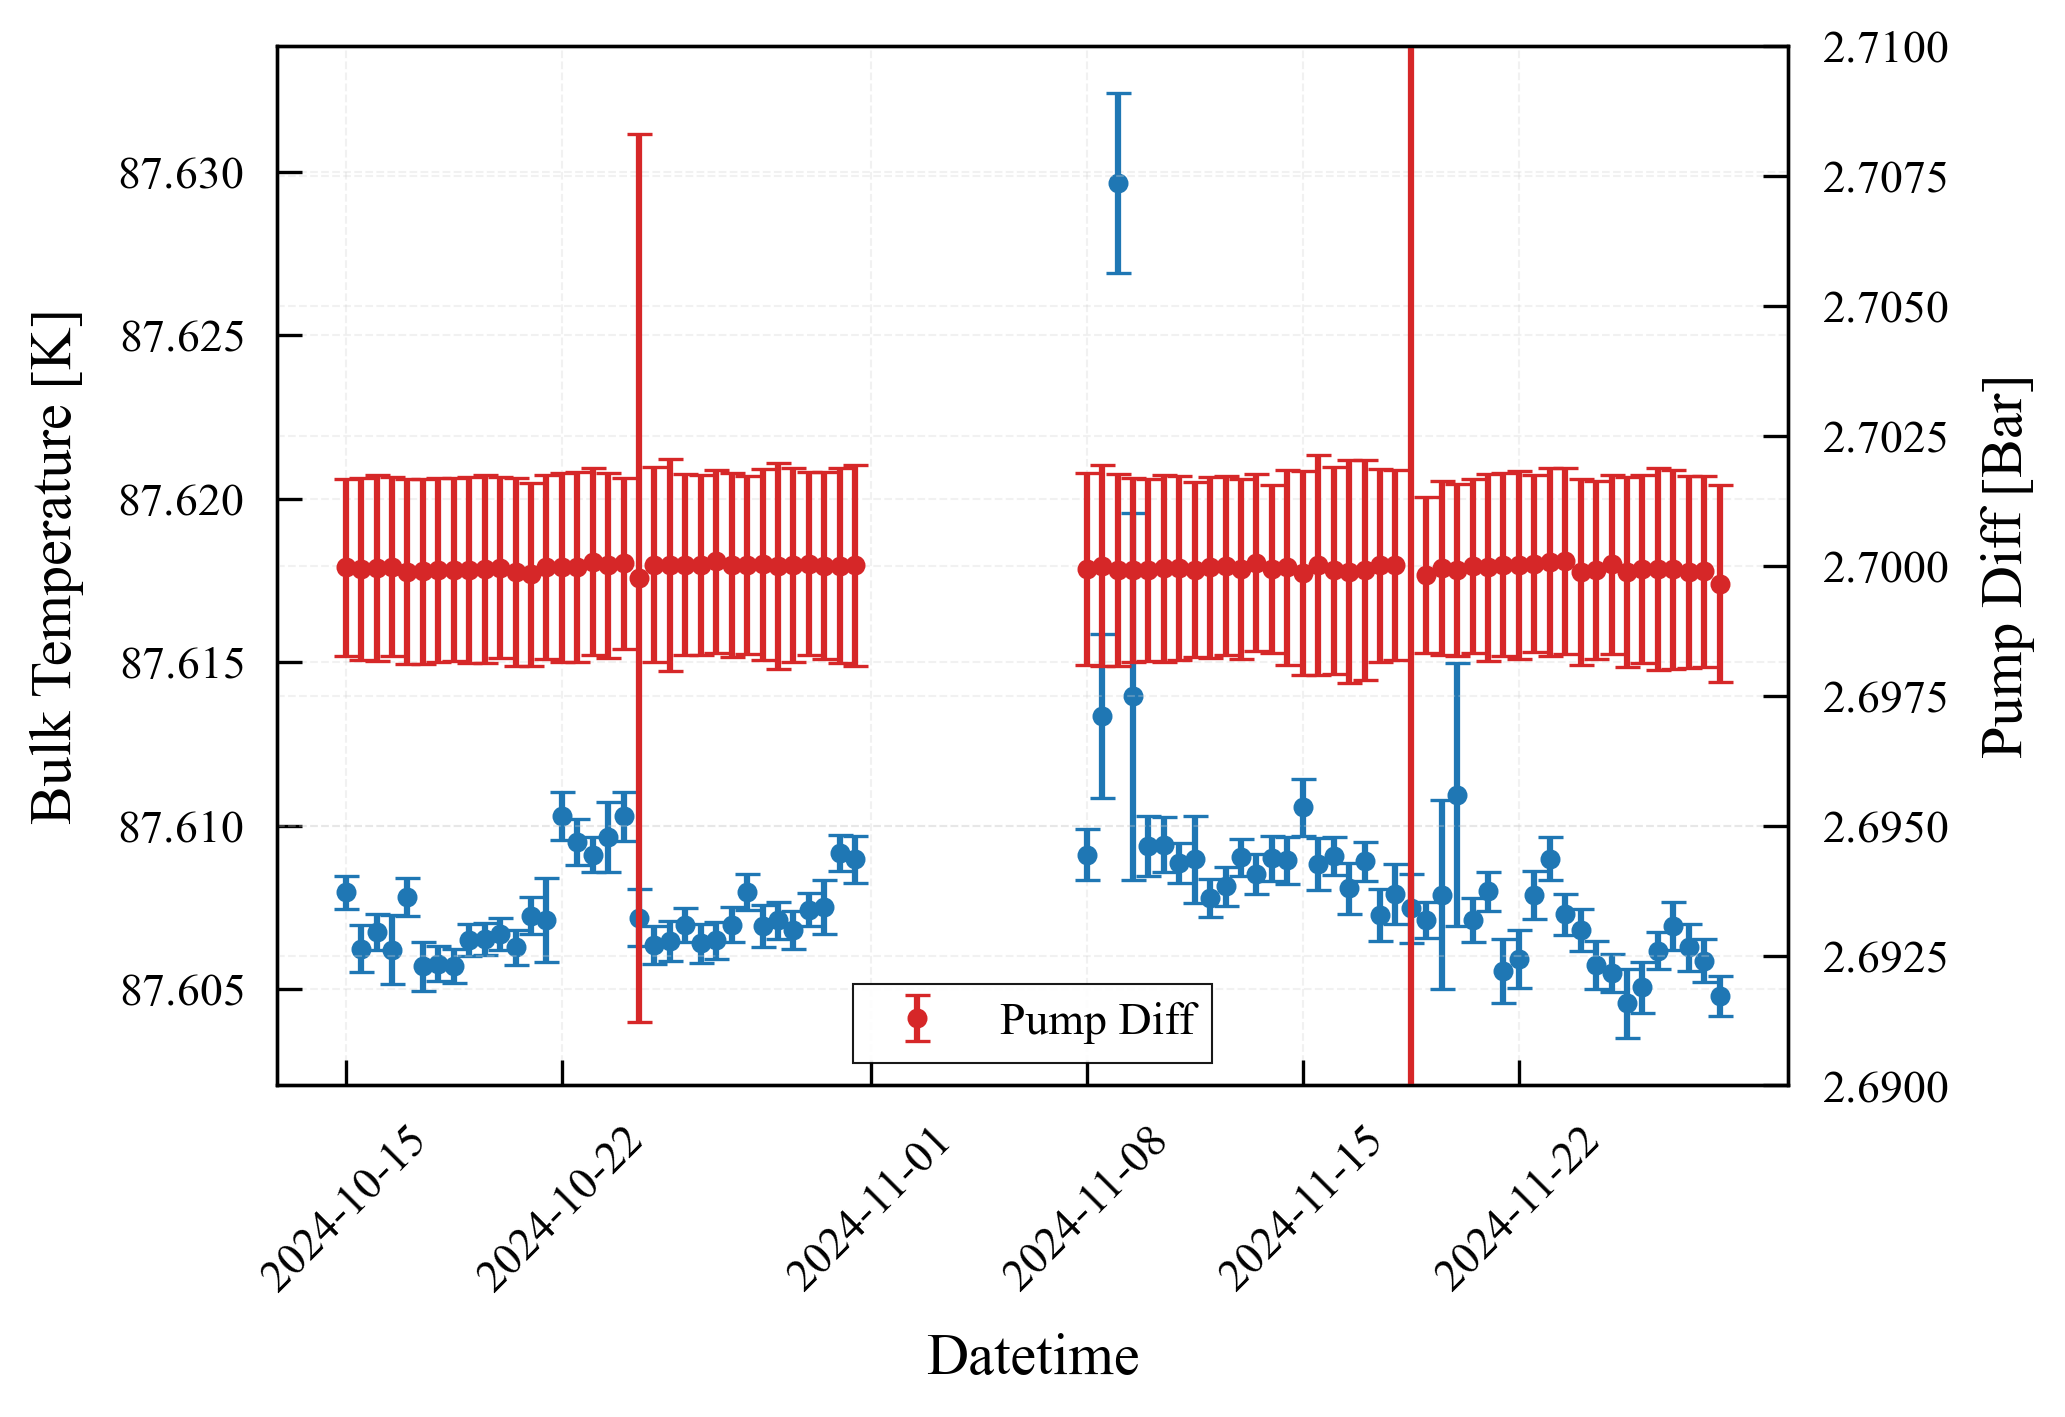

In [ ]:
def line(x, m, b):
    return m*x + b

fig, axes = plt.subplots(1,1)
axes.errorbar(bulk_second.bulk["october"]["data"].resample("12H").mean().index.values, bulk_second.bulk["october"]["data"]["temp"].resample("12H").mean().values, yerr=bulk_second.bulk["october"]["data"]["temp"].resample("12H").std().values, fmt="o")
axes.set_xlabel("Datetime")
axes.set_ylabel("Bulk Temperature [K]")
axes.tick_params(axis='x', rotation=45)

# Convert to numeric (days since epoch)
datetime_index = bulk_second.bulk["october"]["data"].resample("45min").mean().dropna().index
numeric_times = datetime_index.astype('int64') / 1e9 / (24 * 3600)  # Convert nanoseconds to days
temp_values = bulk_second.bulk["october"]["data"]["temp"].resample("45min").mean().dropna().values

# Fit line
popt, _ = curve_fit(line, numeric_times, temp_values)
m, b = popt

# Create datetime range for plotting
start_date = datetime_index.min()
end_date = datetime_index.max()
datetime_fit = pd.date_range(start=start_date, end=end_date, periods=100)
numeric_fit = datetime_fit.astype('int64') / 1e9 / (24 * 3600)

# Calculate fitted line
y_fit = line(numeric_fit, m, b)

# Plot using datetime
# axes.plot(datetime_fit, y_fit, 'r-', linewidth=2, label=fr"Slope: {1e3*m:.1f} mK/day")

residuals = bulk_second.bulk["october"]["data"]["temp"].resample("45min").mean().dropna().values - line(numeric_times, m, b)

hist, bin_edges = np.histogram(residuals, bins=30, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Initial guess for Gaussian parameters
mu_guess = np.mean(residuals)
sigma_guess = np.std(residuals)
A_guess = np.max(hist)

# Fit Gaussian
popt, pcov = curve_fit(gaussian, bin_centers, hist,
                    p0=[mu_guess, sigma_guess, A_guess],
                    maxfev=1000)

mu_fit, sigma_fit, A_fit = popt

mu_err = np.sqrt(pcov[0, 0])  # Error on mean
sigma_err = np.sqrt(pcov[1, 1])  # Error on sigma
A_err = np.sqrt(pcov[2, 2])  # Error on amplitude

# axes.legend(
#     [fr"Residuals $\sigma_G$: {1e3*sigma_fit:.2f} $\pm$ {1e3*sigma_err:.2f} mK"]
# )

axes2 = axes.twinx()
axes2.errorbar(pump_diff.data.resample("12H").mean().index.values, pump_diff.data.resample("12H").mean().values, yerr=pump_diff.data.resample("12H").std().values, color="tab:red", fmt="o", linestyle="none", label="Pump Diff")
axes2.set_ylabel("Pump Diff [Bar]")
axes2.set_ylim(2.69, 2.71)
axes2.legend()
# fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/TMAPS/stability_bulk_second.png", dpi=300)
